# Проект: Исследование данных о российском кинопрокате

**Описание и задачи проекта:**

Заказчик исследования — Министерство культуры Российской Федерации. 
Необходимо изучить рынок российского кинопроката и выявить текущие тренды.
Уделить внимание фильмам, которые получили государственную поддержку и ответить на вопрос, насколько такие фильмы интересны зрителю. 

**Данные для исследования:**

Данные с портала открытых данных Министерства культуры. 
Набор данных содержит информацию о прокатных удостоверениях, сборах и государственной поддержке фильмов, а также информацию с сайта КиноПоиск. 



**Описание данных:**

Таблица mkrf_movies содержит информацию из реестра прокатных удостоверений. У одного фильма может быть несколько прокатных удостоверений. 
 - title — название фильма.
 - puNumber — номер прокатного удостоверения.
 - show_start_date — дата премьеры фильма.
 - type — тип фильма.
 - film_studio — студия-производитель.
 - production_country — страна-производитель.
 - director — режиссёр.
 - producer — продюсер.
 - age_restriction — возрастная категория.
 - refundable_support — объём возвратных средств государственной поддержки.
 - nonrefundable_support — объём невозвратных средств государственной поддержки.
 - financing_source — источник государственного финансирования.
 - budget — общий бюджет фильма. Данные в этом столбце указаны только для тех фильмов, которые получили государственную поддержку.  
 - ratings — рейтинг фильма на КиноПоиске.
 - genres — жанр фильма.
 
Таблица mkrf_shows содержит сведения о показах фильмов в российских кинотеатрах.
 - puNumber — номер прокатного удостоверения.
 - box_office — сборы в рублях.

**Содержание работ:**

**1. Открытие файлов с данными и формирование в один датафрейм.**

- чтение и вывод основной информации о датафреймах

- установка настройки для приведения в нормальный числовой формат

- приведение названия столбца к единому стилю

- обработка аномалий в датафрейме

- объединение таблиц

**2. Предобработка данных.**

- изменение типов данных

- заполнение пропусков

- проверка и обработка дубликатов

- изучение категориальных столбцов, выявление и устранение аномалий

- изучение количественных столбцов, выявление и устранение выбросов

- добавление новых столбцов

**3. Исследовательский анализ данных. Анализ фильмов , вышедших в прокат.**

- кол-во фильмов, вышедших в прокат в динамике по годам

- изменение доли кол-ва фильмов в прокате от кол-ва аккредитованных фильмов

- изучение типов фильмов аккредитованных и в прокате

- динамика проката по годам. Максимальная и минимальная сумма сборов

- изучение возрастного ограничения аудитории («6+», «12+», «16+», «18+» и т. д.) на сборы фильма в прокате в период с 2015 по 2019 год

**4. Исследовательский анализ данных. Исследование фильмов, которые получили государственную поддержку.**

- динамика изменения бюдежетов на производство фильмов и гос. финансирования по годам

- определение доли финансируемых фильмов от кол-ва российских аккредитованных фильмов

- определение влияния бюджета  фильма на сумму гос. финансирования, возвратных и невозвратных средств.

- определение типов и жанров финасируемых фильмов

- определение возрастной категории финасируемых фильмов

- определение самых дорогостояего жанра

- анализ рейтингов финансируемых фильмов

- изучение окупаемости фильмов в прокате

- изучение влияния рейтинга и бюджета фильма на окупаемость

**5. Общий вывод.**

## Открытие файлов с данными и формирование в один датафрейм

### Чтение и вывод основной информации о датафреймах

In [1]:
# Импорт библиотеки pandas.
# Чтение первого файла с данными и сохранение в датафрейм "данные о прокатных удостоверениях"
import pandas as pd
movies = pd.read_csv('****')
movies.head(3)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


In [2]:
# Выводим основную информации о первом датафреме.
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

In [3]:
# Чтение второго файла с данными и сохранение в датафрейм "данные о прокате в российских кинотеатрах"
shows = pd.read_csv('/datasets/mkrf_shows.csv')
shows.head()

,puNumber,box_office
0,111000113,2.450000e+03
1,111000115,6.104000e+04
2,111000116,1.530300e+08
3,111000117,1.226096e+07
4,111000118,1.636841e+08


### Установка настройки для приведения в нормальный числовой формат

In [4]:
# Устанавливаем настройку для приведения в нормальный числовой формат
pd.options.display.float_format = '{:.2f}'.format

In [5]:
# Выводим первые 5 строк второго датафрейма
shows.head()

,puNumber,box_office
0,111000113,2450.00
1,111000115,61040.00
2,111000116,153030013.40
3,111000117,12260956.00
4,111000118,163684057.79


In [6]:
# Выводим основную информации о втором датафреме.
shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


### Приведение названия столбца к нижнему регистру

In [7]:
# Приведение названия столбца к единому стилю.
movies.rename(columns ={'puNumber':'pu_number'},inplace = True)

In [8]:
# Приведение названия столбца к единому стилю.
shows.rename(columns ={'puNumber':'pu_number'},inplace = True)

### Обработка аномалий в датафрейме

**Объединим два датафрейм.**

**Объединять будем по столбцу "pu_number" - уникальные номера прокатных удостоверений, которые есть в обоих датафреймах.**

**Для этого необходимо сначала привести к правильному типу данных столбец 'pu_number' в датафрейм movies.**

In [9]:
# Отсортируем данные, чтобы вычислить аномалии .
movies['pu_number'].sort_values(ascending=False)

1797           нет
5249     231001111
1011     231001012
3992     226019110
4355     226017410
           ...    
1128     111000113
729      111000112
4768     111000111
3962     111000110
804      111004112
Name: pu_number, Length: 7486, dtype: object

In [10]:
# Выведем фильм с отсутствующим номером удостоверения .
movies[movies['pu_number']=='нет']

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
1797,Курбан-роман. (История с жертвой),нет,2014-05-15T12:00:00.000Z,Художественный,"ФОНД ""ИННОВАЦИЯ""",Россия,С.Юзеев,М.Галицкая,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN


**На сайте министерства провела проверку данного показа, на сайте также не указан номер удостоверения.
Однако на сайте нашлась информация по аналогичному фильму, у которого была другая дата показа.
В нашем датафрейме также есть данная информация.**

**Удалим строку с отсутствующим удостоверением.**


In [11]:
# Выведем другие строки с аналогичным названием фильма .
movies[movies['title'].str.contains('Курбан-роман')]

,title,pu_number,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
1797,Курбан-роман. (История с жертвой),нет,2014-05-15T12:00:00.000Z,Художественный,"ФОНД ""ИННОВАЦИЯ""",Россия,С.Юзеев,М.Галицкая,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN
2078,Курбан-роман. (История с жертвой).,111009614,2014-09-02T12:00:00.000Z,Художественный,"ФОНД ""ИННОВАЦИЯ""",Россия,С.Юзеев,М.Галицкая,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Удалим строку
movies = movies[movies['pu_number']!='нет']

In [13]:
# Приведем в соответствующий тип данных столбец с номером удовстоверения
movies['pu_number'] = movies['pu_number'].astype('int64')

**Для подготовки к объединению датафреймов, уберем дубликаты, если они есть  и построим сводную из датафрейма с данными о прокате в кинотеатрах, чтобы вывести сумму проката по каждому номеру удостоверения. Для объединения таблиц номера удостоверений не должны повторяться.**

In [14]:
# Проверяем наличие явных дубликатов
shows.duplicated().sum()

0

### Объединение таблиц

In [15]:
# Строим сводную таблицу по второму датафрейму.
shows = shows.pivot_table(index='pu_number',values='box_office',aggfunc='sum')

In [16]:
# Сделаем инедксом номера удостоверений в первой таблице
movies.set_index('pu_number', inplace=True)
movies.head(3)

,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
pu_number,,,,,,,,,,,,,,
221048915,Открытый простор,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
111013716,Особо важное задание,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
221038416,Особо опасен,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


In [17]:
# Добавляем в таблицу с данными о прокате столбец с данными о прокате из второй таблицы, по индексу.
movies['box_office'] = shows['box_office']
movies.head(3)

,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
pu_number,,,,,,,,,,,,,,,
221048915,Открытый простор,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
111013716,Особо важное задание,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
221038416,Особо опасен,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


In [18]:
# Возвращаем в индекс нумерацию строк
movies.reset_index(inplace=True)
movies.head(3)

,pu_number,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,221048915,Открытый простор,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,111013716,Особо важное задание,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,221038416,Особо опасен,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


In [19]:
# Выводим финальную инфнормацию о получившемся датафрейме.
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7485 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pu_number              7485 non-null   int64  
 1   title                  7485 non-null   object 
 2   show_start_date        7485 non-null   object 
 3   type                   7485 non-null   object 
 4   film_studio            7467 non-null   object 
 5   production_country     7483 non-null   object 
 6   director               7476 non-null   object 
 7   producer               6917 non-null   object 
 8   age_restriction        7485 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

## Предобработка данных

### Изменение типов данных

In [20]:
# Выводим статистические данные по всем числовым столбцам
movies.describe()

,pu_number,refundable_support,nonrefundable_support,budget,box_office
count,7485.00,332.00,332.00,332.00,3158.00
mean,135196587.56,11864457.83,48980988.89,127229716.68,76478696.16
std,38352919.34,24916555.26,59980117.92,188588333.12,240353122.82
min,1811096.00,0.00,0.00,0.00,0.00
25%,112025118.00,0.00,25000000.00,42000000.00,86239.00
50%,121015510.00,0.00,30000000.00,68649916.00,2327987.55
75%,124003314.00,15000000.00,40375000.00,141985319.50,23979671.02
max,231001111.00,180000000.00,400000000.00,2305074303.00,3073568690.79


**По статистическому  срезу числовых столбцов можно сделать вывод , что в столбцах ниже округленные данные, соответсвенно, для экономии памяти их можно привести в тип данных int:**

- refundable_support - перевести в целое число

- nonrefundable_support - перевести в целое число

- budget - перевести в целое число

**А также из строковых типов данных необходимо изменить:**

- show_start_date - строковый формат необходимо перевести в формат даты, для проведения операций с датами

- ratings - перевести в числовое значение с плавающей точкой, для проведений анализа поданному критерию.


In [21]:
# Приведение к корректому типу данных
movies['show_start_date'] = pd.to_datetime(movies['show_start_date'], format='%Y-%m-%d').dt.date.astype('datetime64')
movies.head(3)

,pu_number,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,221048915,Открытый простор,2015-11-27,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,111013716,Особо важное задание,2016-09-13,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,221038416,Особо опасен,2016-10-10,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


In [22]:
# Выведем список уникальных значений по колонке "рейтинг"
movies['ratings'].unique()

array(['7.2', '6.6', '6.8', '7.7', '8.3', '8.0', '7.8', '8.1', '7.1',
       '6.0', '7.4', '5.8', '8.7', '6.3', '6.9', '5.0', '4.3', '7.3',
       '7.0', '6.4', nan, '8.2', '7.5', '6.7', '7.9', '5.9', '6.2', '5.6',
       '6.5', '2.4', '7.6', '6.1', '8.6', '8.5', '8.8', '5.5', '5.1',
       '5.7', '5.4', '99%', '4.4', '4.5', '5.3', '4.1', '8.4', '2.6',
       '3.8', '4.6', '4.8', '4.0', '3.0', '1.6', '4.2', '5.2', '4.7',
       '4.9', '3.9', '2.7', '3.3', '2.9', '28%', '3.7', '1.4', '3.1',
       '97%', '3.5', '3.2', '2.8', '1.5', '2.1', '2.5', '9.2', '3.4',
       '1.1', '3.6', '83%', '64%', '91%', '94%', '62%', '79%', '90%',
       '19%', '88%', '1.0', '89%', '1.3', '1.9', '1.8', '1.2', '1.7',
       '9.0', '98%', '8.9', '9.1'], dtype=object)

**Ряд значения в колонке "рейтинг" с аномалиями. Скорее всего при переносе данных с Кинопоиска произошла либо ручная , либо техническая ошибка, в зависимости от того, каким образом данные попадают в статистику министерства культуры.
Приведем данные с процентами к нормальноум виду.**


In [23]:
# Убираем из значений знак % 
movies['ratings'] = movies['ratings'].str.replace('%', '')
# Выведем список уникальных значений после обработки 
movies['ratings'].unique()

array(['7.2', '6.6', '6.8', '7.7', '8.3', '8.0', '7.8', '8.1', '7.1',
       '6.0', '7.4', '5.8', '8.7', '6.3', '6.9', '5.0', '4.3', '7.3',
       '7.0', '6.4', nan, '8.2', '7.5', '6.7', '7.9', '5.9', '6.2', '5.6',
       '6.5', '2.4', '7.6', '6.1', '8.6', '8.5', '8.8', '5.5', '5.1',
       '5.7', '5.4', '99', '4.4', '4.5', '5.3', '4.1', '8.4', '2.6',
       '3.8', '4.6', '4.8', '4.0', '3.0', '1.6', '4.2', '5.2', '4.7',
       '4.9', '3.9', '2.7', '3.3', '2.9', '28', '3.7', '1.4', '3.1', '97',
       '3.5', '3.2', '2.8', '1.5', '2.1', '2.5', '9.2', '3.4', '1.1',
       '3.6', '83', '64', '91', '94', '62', '79', '90', '19', '88', '1.0',
       '89', '1.3', '1.9', '1.8', '1.2', '1.7', '9.0', '98', '8.9', '9.1'],
      dtype=object)

In [24]:
# Приведем к числовому типу данных колонку
movies['ratings'] = movies['ratings'].astype('float')

In [25]:
# Разделим на 10 все числа, коорые были с процентами и выведем получившийся список уникальных значений.
movies.loc[movies['ratings'] > 10, 'ratings'] = movies['ratings']/10
movies['ratings'].unique()

array([7.2, 6.6, 6.8, 7.7, 8.3, 8. , 7.8, 8.1, 7.1, 6. , 7.4, 5.8, 8.7,
       6.3, 6.9, 5. , 4.3, 7.3, 7. , 6.4, nan, 8.2, 7.5, 6.7, 7.9, 5.9,
       6.2, 5.6, 6.5, 2.4, 7.6, 6.1, 8.6, 8.5, 8.8, 5.5, 5.1, 5.7, 5.4,
       9.9, 4.4, 4.5, 5.3, 4.1, 8.4, 2.6, 3.8, 4.6, 4.8, 4. , 3. , 1.6,
       4.2, 5.2, 4.7, 4.9, 3.9, 2.7, 3.3, 2.9, 2.8, 3.7, 1.4, 3.1, 9.7,
       3.5, 3.2, 1.5, 2.1, 2.5, 9.2, 3.4, 1.1, 3.6, 9.1, 9.4, 9. , 1.9,
       1. , 8.9, 1.3, 1.8, 1.2, 1.7, 9.8])

In [26]:
# Приведем к целочисленныму типу данных колонки:
movies[['refundable_support', 'nonrefundable_support', 'budget' ]] = movies[['refundable_support', 'nonrefundable_support', 'budget']].astype('Int64')

In [27]:
# Финально проверяем корректность типа данных всех колонок
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7485 entries, 0 to 7484
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   pu_number              7485 non-null   int64         
 1   title                  7485 non-null   object        
 2   show_start_date        7485 non-null   datetime64[ns]
 3   type                   7485 non-null   object        
 4   film_studio            7467 non-null   object        
 5   production_country     7483 non-null   object        
 6   director               7476 non-null   object        
 7   producer               6917 non-null   object        
 8   age_restriction        7485 non-null   object        
 9   refundable_support     332 non-null    Int64         
 10  nonrefundable_support  332 non-null    Int64         
 11  budget                 332 non-null    Int64         
 12  financing_source       332 non-null    object        
 13  rat

**Все колонки приведены в порядок по типам данных.**

### Изучение и заполнение пропусков

In [28]:
# Выведем информацию по кол-ву пропусков в колонках
movies.isna().sum()

pu_number                   0
title                       0
show_start_date             0
type                        0
film_studio                18
production_country          2
director                    9
producer                  568
age_restriction             0
refundable_support       7153
nonrefundable_support    7153
budget                   7153
financing_source         7153
ratings                   966
genres                    975
box_office               4327
dtype: int64

**Колонки с пропущеными значениями:**

- film_studio,  director - не много пропущенных значений, можно заменить на значение "не определено".

- production_country - пропущено 2 значения, потеря даных минимальная, можно не заполнять, но скорее всего по описанию в других колонках можно идентифицировать страну производства, поэтому заполним пропуски. 

- producer - пропущено около 7% в данных, но заполнить эти данные не представялется возможным , заполним значением"не определено".

- refundable_support - объём возвратных средств государственной поддержки: если нет данных, значит, гос поддержка отсутсвует. Нулями пропуски заполнить нельзя, так как это повлияет на расчеты. Пропуски не заполняем.

- nonrefundable_support - объём невозвратных средств государственной поддержки:  если нет данных, значит, гос поддержка отсутсвует. Нулями пропуски заполнить нельзя, так как это повлияет на расчеты. Пропуски не заполняем.

- budget - общий бюджет фильма: если нет данных, значит, гос поддержка отсутсвует. Нулями пропуски заполнить нельзя, так как это повлияет на расчеты. Пропуски не заполняем.

- financing_source - источник государственного финансирования, если нет данных, значит, гос поддержка отсутсвует. заполнить "без поддержки".

- ratings  - отсутствует 12,9 % данных.  Возможно фильмы не набрали минимальное число голосований для составления рейтинга или фильмы не вышли в прокат. Нулями пропуски заполнить нельзя, так как это повлияет на расчеты. Пропуски не заполняем.

- genres - также отсутствует 13% данных. Причиной пропусков может быть ручное заполнение данных о прокате фильма, скорее всего пункт был случайно пропущен. Но вручную восстановить данные не представляется возможным. Заполним пропуски значением "не определено".

- box_office - сборы в рублях, все данные из датафрейма по сборам были перенесены, значит, по остальным фильмам нет данных, возможно фильм не вышел, был снят с проката. Нулями пропуски заполнить нельзя, так как это повлияет на расчеты. Пропуски не заполняем.

In [29]:
# Заполняем пропуски 
movies[['film_studio', 'director','producer','genres']] = movies[['film_studio', 'director','producer','genres']].fillna('не определено')

In [30]:
# Выведем пропуски в колоке "страна производства"
movies.loc[movies['production_country'].isna()]

,pu_number,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
3185,111001216,"Детский юмористический киножурнал ""Ералаш. Ну ...",2016-02-09,Художественный,"ООО ""Продюсерский центр ЕРАЛАШ""",NaN,"Р.Светлов, И.Магитон, А.Арутюнян, Л.Мирский, А...","ООО ""Продюсерский центр ЕРАЛАШ""",«0+» - для любой зрительской аудитории,<NA>,<NA>,<NA>,NaN,7.20,"детский,комедия",194527.00
4440,214000410,Мульт личности. Выпуск 5,2010-01-25,Художественный,не определено,NaN,не определено,не определено,«0+» - для любой зрительской аудитории,<NA>,<NA>,<NA>,NaN,4.00,"мультфильм,комедия",NaN


**По названиям ясно, что это фильмы российского производства.**

In [31]:
# Заполним пропуски значением "Россия"
movies['production_country'] = movies['production_country'].fillna('Россия')

In [32]:
# Заполним пропуски 
movies['financing_source'] = movies['financing_source'].fillna('без поддержки')

### Проверка и обработка дубликатов

In [33]:
# Поиск явных дубликатов
movies.duplicated().sum()

0

**Явных дубликатов строк нет.**

**Также важно проверить, нет ли дубликатов в номерах прокатных удостоверений, а также могут ли повторяться в списке одни и те же фильмы.**


In [34]:
# Выводим дубликаты по названиям фильмов
movies['title'].duplicated().sum()

714

**Определено 714 дубликата по названиям фильмов.**

**Рассмотрим подробнее, что это за фильмы.**

In [35]:
# Выведем первые 20 строк с повторяющимися фильмами
movies[movies['title'].duplicated()].head(20)

,pu_number,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
3,221026916,Особо опасен,2016-06-10,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,<NA>,<NA>,<NA>,без поддержки,6.80,"фантастика,боевик,триллер",NaN
4,221030815,Особо опасен,2015-07-29,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,<NA>,<NA>,<NA>,без поддержки,6.80,"фантастика,боевик,триллер",NaN
41,221004616,Алекс и Эмма,2016-02-09,Художественный,"Эскейп Артистс, Франчайз Пикчерз, Рейнер-Грэйс...",США,Роб Райнер,"Тодд Блэк, Элан Грейсман, Джереми Левен, Роб Р...",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,6.40,"мелодрама,комедия",NaN
110,121026316,Гарри Поттер и орден Феникса /По роману Дж.К.Р...,2016-09-23,Художественный,"Уорнер Бразерс, Хэйдей Филмз",США - Великобритания,Дэвид Йетс,"Дэйвид Баррон, Дэйвид Хейман",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,7.70,"фэнтези,приключения,семейный",759526.00
113,121026116,Гарри Поттер и узник Азкабана /По роману Дж.К....,2016-09-23,Художественный,"Хэйдей Филмз, 1492 Пикчерз, Уорнер Бразерс",США,Альфонсо Куарон,Майкл Барната,«12+» - для детей старше 12 лет,<NA>,<NA>,<NA>,без поддержки,8.20,"фэнтези,приключения,семейный",1125302.00
122,121026216,Гарри Поттер и кубок огня /По роману Дж.К.Ролинг/,2016-09-23,Художественный,"Уорнер Бразерс, Хэйдэй Филмз",США - Великобритания,Майк Ньюэлл,Дэйвид Хейман,«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,7.90,"фэнтези,приключения,семейный",843310.00
132,221035716,Джейн Эйр /По одноименному роману Шарлотты Бро...,2016-06-07,Художественный,"Чинеритино, Флаш Фильм, Медиасет, Мирамакс, Ро...",Франция - Италия - Великобритания - США,Франко Дзеффирелли,не определено,«12+» - для детей старше 12 лет,<NA>,<NA>,<NA>,без поддержки,7.40,"драма,мелодрама",NaN
205,221001815,Кинг Конг _,2015-02-11,Художественный,"Биг Праймейт Пикчерз, Юниверсал Пикчерз, ВингН...",Новая Зеландия - США,Питер Джексон,"Йен Бленкин, Питер Джексон, Кэролайн Каннингэм...",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,7.60,"боевик,драма,мелодрама",NaN
268,121009103,Пуленепробиваемый.,2013-03-13,Художественный,"Лейкшор Интертейнмент, Мозаик Медиа Груп, Сайн...",США,Пол Хантер,"Джон Ву, Чарльз Ровен, Дуглас Сегал, Теренс Чанг",«12+» - для детей старше 12 лет,<NA>,<NA>,<NA>,без поддержки,6.70,"фэнтези,боевик,комедия",NaN
379,224026712,Рапунцель: Запутанная история,2012-10-23,Анимационный,"Уолт Дисней Анимейшн Студиос, Уолт Дисней Пикчерз",США,"Натан Грино, Байрон Ховард",Рой Конли,«12+» - для детей старше 12 лет,<NA>,<NA>,<NA>,без поддержки,7.90,"мультфильм,мюзикл,фэнтези",NaN


В списке есть одни и те же фильмы, которые были несколько раз в прокате, таким фильмам были выданы несколько раз номера удостоверений, для каждой даты проката.

In [36]:
# Выведем список уникальных названий фильмов.
sorted(movies['title'].unique().tolist())

[' Я ПРЕПОД',
 '"SOS" над тайгой',
 '"V" значит вендетта',
 '"АРТиШОК" анимационный альманах авторских фильмов',
 '"Бежин луг" Сергея Эйзенштейна',
 '"Державная" Размышления 100 лет спустя',
 '"Зеленое яблоко" анимационный альманах выпуск № 7',
 '"Машины песенки". Серия "Опять Новый Год!"',
 '"Море"',
 '"Сезон дождей", "Диета Матроскина", "Шарик хочет телефон" из анимационного сериала "Простоквашино"',
 '"Старый" Новый год',
 '"Уорнер Бразерс Пикчерз" и "Леджендари Пикчерз": Тихоокеанский рубеж',
 '"Фееринки". Серия "Фантик спешит на помощь"',
 '"Хороший день", "Бог из машины/Deus EX", "Голод", "Психотроника", "Темная ночь"',
 '"Чудовище из Простоквашино", "Ген героя", "Ненастоящий детектив", "Мама и Тама", "Как бы не стало зимы" из анимационного сериала "Простоквашино"',
 '#ВСЁ_ИСПРАВИТЬ!?!',
 '#Москва-Руаян',
 '#ЯВОЛОНТЕР Истории неравнодушных',
 '(Не)жданный принц',
 '(Не)идеальный мужчина',
 '... в стиле JAZZ',
 '... и я там был',
 '... имени Сергея Герасимова',
 '007 Координаты Ск

**В списке с названимия фильмов есть неявные дубликаты, фильмы с одинаковыми названиями, отличающиеся в написании разными символами, например, лишний пробел, точками, нижними подчеркиваниями или разной формой написания, а именно краткое название или название с указанием режиссера, указанием года  и тд.**

**Таких дубликатов большое количество, обработать вручную не представляется возможным, мы наверняка не знаем один и тот же это фильм или это разные фильмы с одинаковым названием.**

**Проверим также, возможно у некоторых повторяющихся фильмов указан прпущенный рейтинг фильма или жанр, тогда мы сможем дополнить пропущенные данные.**

In [37]:
# Добавим столбец с булевым значением "True", если рейтинг отсутствует.
movies['ratings_nan'] = movies['ratings'].isna()

**Построим сводную таблицу, в которой будет указано количество повторений фильма и количество пропусков в колонке "рейтинг".**

In [38]:
# Строим сводную таблицу
movies_ratings = movies.pivot_table(index='title', values='ratings_nan',aggfunc=['count','sum'])
movies_ratings.columns = ['count_total', 'count_nan']
# Выведем все повторяющиеся фильмы, у которых не указан рейтинг 
movies_ratings.query('count_nan > 0 and count_total > 1 ')

,count_total,count_nan
title,,
Аниматор,2,2
З/Л/О: Новый вирус,2,2
Забытые войны России,2,2
"Легион_.(Фильм содержит сцены ужасов, насилия и жестокости)",2,2
"Машкины Страшилки. Серия ""Чудовищная правда о том, как страшно быть маленьким""",2,2
Однажды в Риме,2,2
Руби и повелитель воды,2,2
Три сестры,2,2
Ян Антонышев,2,2


**Нет ни одного повторяющегося фильма, у которого был был указан рейтинг.**

**Проделаем аналогичную операцию с жанрами.**

In [39]:
# Добавим столбец с булевым значением "True", жанр отсутствует.
movies['genres_nan'] = movies['genres']=='не определено'

In [40]:
# Строим сводную таблицу
movies_genres = movies.pivot_table(index='title', values='genres_nan',aggfunc=['count','sum'])
movies_genres.columns = ['count_total', 'count_nan']
# Выведем все повторяющиеся фильмы, у которых не указан жанр 
movies_genres.query('count_nan > 0 and count_total > 1 ')

,count_total,count_nan
title,,
Аниматор,2,2
З/Л/О: Новый вирус,2,2
Забытые войны России,2,2
"Легион_.(Фильм содержит сцены ужасов, насилия и жестокости)",2,2
"Машкины Страшилки. Серия ""Чудовищная правда о том, как страшно быть маленьким""",2,2
Однажды в Риме,2,2
Руби и повелитель воды,2,2
Три сестры,2,2
Ян Антонышев,2,2


**Нет ни одного повторяющегося фильма, у которого был был указан жанр.**

**Проверим дубликаты в номерах удостоверений проката.**

In [41]:
movies['pu_number'].duplicated().sum()

2

**Обнаружены 2 дубликата.**

**Найдем данные дубликаты.**

In [42]:
# Построим сводную таблицу с количеством повторений номеров удостоверений.
(
    movies
    .pivot_table(index = 'pu_number', values = 'title', aggfunc = 'count')
    .sort_values(by='title',ascending=False)
    .head()
)

,title
pu_number,
221054410,2
221154310,2
1811096,1
121029216,1
121029412,1


In [43]:
# Выведем информацию о данных фильмах
movies.query('pu_number==221054410 or pu_number==221154310')

,pu_number,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,ratings_nan,genres_nan
4637,221154310,Как жениться и остаться холостым,2010-12-17,Художественный,"Ше Вам, Скрипт Ассосье, Тэ Фэ 1 Фильм Продюксь...",Франция,Эрик Лартиго,"Амандин Било, Алан Шаба",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,7.00,"мелодрама,комедия",NaN,False,False
4638,221154310,Иоанна - женщина на папском престоле /По роман...,2010-12-17,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне ...",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,7.60,"драма,мелодрама,история",NaN,False,False
5066,221054410,Анализируй это!,2010-05-25,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,7.40,"комедия,криминал",NaN,False,False
5067,221054410,Анализируй то!,2010-05-25,Художественный,"Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи...",США,Гарольд Реймис,"Джейн Розенталь, Паул Уэйнстейн",«12+» - для детей старше 12 лет,<NA>,<NA>,<NA>,без поддержки,6.80,"комедия,криминал",NaN,False,False


**Проверив на сайте министерства :
Для фильмов "Анализируй это!" и "Анализируй то!" одно удостоверение выдавалось в одно и тоже время проката, соответственно, номер удостоверения верный и удалить или заменить нельзя.**

**С фильмами "Как жениться и остаться холостым" и "Иоанна - женщина на папском престоле" аналогичная ситуация.**

**Также есть другие даты проката этих фильмов, но они также есть в нашем датафрейме. Соответсвенно, оставляем данные как есть.**

**Данные из министерства:**

**Как жениться и остаться холостым:https://opendata.mkrf.ru/opendata/7705851331-register_movies/**

- pu_number 221154310, дата проката 2010-12-17

- pu_number 221142510, дата проката 2010-12-03

**Иоанна - женщина на папском престоле: https://opendata.mkrf.ru/opendata/7705851331-register_movies/**

- pu_number221154310, дата проката 2010-12-17

- pu_number221141710, дата проката 2010-12-03

**Анализируй это! и Анализируй то!: https://opendata.mkrf.ru/opendata/7705851331-register_movies/**

- pu_number 221054410, дата проката 2010-05-25

- pu_number 221147310, дата проката 2010-12-15

In [44]:
movies.query('title=="Как жениться и остаться холостым"\
or title=="Иоанна - женщина на папском престоле /По роману Донны Вулфольк Кросс/"\
or title=="Анализируй это!"\
or title=="Анализируй то!"')

,pu_number,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,ratings_nan,genres_nan
4049,121005410,Иоанна - женщина на папском престоле /По роман...,2010-03-25,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне ...",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,7.60,"драма,мелодрама,история",NaN,False,False
4512,221141710,Иоанна - женщина на папском престоле /По роман...,2010-12-03,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне ...",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,7.60,"драма,мелодрама,история",NaN,False,False
4519,221142510,Как жениться и остаться холостым,2010-12-03,Художественный,"Ше Вам, Скрипт Ассосье, Тэ Фэ 1 Фильм Продюксь...",Франция,Эрик Лартиго,"Амандин Било, Алан Шаба",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,7.00,"мелодрама,комедия",NaN,False,False
4552,221147310,Анализируй это!,2010-12-15,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,7.40,"комедия,криминал",NaN,False,False
4637,221154310,Как жениться и остаться холостым,2010-12-17,Художественный,"Ше Вам, Скрипт Ассосье, Тэ Фэ 1 Фильм Продюксь...",Франция,Эрик Лартиго,"Амандин Било, Алан Шаба",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,7.00,"мелодрама,комедия",NaN,False,False
4638,221154310,Иоанна - женщина на папском престоле /По роман...,2010-12-17,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне ...",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,7.60,"драма,мелодрама,история",NaN,False,False
5066,221054410,Анализируй это!,2010-05-25,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,7.40,"комедия,криминал",NaN,False,False
5067,221054410,Анализируй то!,2010-05-25,Художественный,"Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи...",США,Гарольд Реймис,"Джейн Розенталь, Паул Уэйнстейн",«12+» - для детей старше 12 лет,<NA>,<NA>,<NA>,без поддержки,6.80,"комедия,криминал",NaN,False,False


### Изучение категориальных столбцов, выявление и устранение аномалий

**Выведем списки уникальных значений в кагориальных столбцах:**

- film_studio

- production_country

- director

- producer

- genres

- age_restriction

- type

In [45]:
sorted(movies['film_studio'].unique().tolist())

[' АНО "Кинофорум"',
 ' Ауматик Интертейнмент, Блюмхаус Продакшнз и др.',
 ' ЗАО "Кинокомпания ФаворитФильм" по заказу ООО "ФАВОРИТ МЕДИА"',
 ' Константин Фильм, А Эр Ди Дегето Фильм, Дюне Филис, Икури Филмз, Медуза Фильм, У Эф А Интернэшнл Филм энд Ти Ви Продуцион, Юниверсум Филм ',
 ' ООО "АВАТАРА"',
 ' ООО "КОСТАФИЛЬМ"',
 ' ООО "КиноФирма"',
 ' ООО "Кинокомпания "Студия ПРЕССИНГ"',
 ' ООО "Магнум-фильм"',
 ' ООО "Продюсерская фирма Игоря Толстунова"',
 ' ООО "Студия "Рой"',
 ' ООО "Студия 25", ООО "Медиа Арт Студио", ООО "Продюсерский центр "Синема Продакшн" ',
 ' ООО "Студия МЕТРАФИЛЬМС", Компания "TASSE film", Компания "SIRENA film"',
 ' ООО "ТаББаК"',
 ' ООО "ТаББаК", ООО "Анимационная студия "Москва"',
 ' ООО "ТаББаК", ООО "Весёлая Компания"',
 ' ООО "Форс Медиа"',
 ' ООО "Хардкор", ООО "Патриот продакшнс"',
 ' ООО "Энджой мувиз"',
 ' ООО "Энджой мувиз", ООО "Эмоушен Пикчерз", ООО "РЕНОВАЦИО интертейнмент"',
 ' ООО Продюсерский центр "Фёдор Добронравов"',
 ' Юниверсал Пикчерз',


In [46]:
sorted(movies['production_country'].unique().tolist())

[' СССР',
 ' СССР ',
 ' СССР   ',
 '2019',
 'CША',
 'Австралия',
 'Австралия - Великобритания - Бельгия - Индия',
 'Австралия - Германия',
 'Австралия - Ирландия',
 'Австралия - Колумбия',
 'Австралия - США',
 'Австралия, Канада',
 'Австралия, США',
 'Австралия-Великобритания',
 'Австралия-Ирландия',
 'Австралия-США',
 'Австралия-Турция-США',
 'Австрия',
 'Австрия - Германия',
 'Австрия - Германия - Франция',
 'Австрия - Люксембург',
 'Австрия, Великобритания, Германия',
 'Австрия-Германия-Франция',
 'Австрия-Франция-Германия',
 'Азербайджан-Россия',
 'Аргентина',
 'Аргентина - Бразилия',
 'Аргентина - Испания',
 'Аргентина - Испания - Уругвай',
 'Аргентина - Мексика - Бразилия - Франция - США',
 'Аргентина - Уругвай - Россия - Германия - Франция - Нидерланды',
 'Аргентина - Франция - Испания',
 'Аргентина, Испания',
 'Аргентина-Испания',
 'Армения',
 'Армения - Германия',
 'Армения - Казахстан',
 'Армения-Россия',
 'Бельгия',
 'Бельгия - Германия - Люксембург',
 'Бельгия - Германия - 

In [47]:
sorted(movies['director'].unique().tolist())

[' Йохан Нийенхейс',
 ' Н.Орлов, Р.Быков',
 ' Р.Асхаев',
 ' Т.Саакян',
 ' Ф.Бондарчук',
 'Ёлкин Туйчиев',
 'Ён Сан-хо',
 'А Андрющенко',
 'А. Калюжный',
 'А. Кутерье',
 'А.А.Эшпай',
 'А.Аббасов',
 'А.Абидова (псевдоним Аниса Сабири)',
 'А.Аболс',
 'А.Агаджанян',
 'А.Адилханян',
 'А.Адраникян',
 'А.Аксененко',
 'А.Аксененко, Э.Никогосян, Д.Дюжев, А.Вакулов (А.Кульбицкий)',
 'А.Алов, В.Наумов',
 'А.Аманшаев, Г.Шенгелия',
 'А.Амбросьев',
 'А.Амиров',
 'А.Ананикян, В.Рейнгеверц',
 'А.Андрианов',
 'А.Андризани, А.Бардани, В.Карнелутти, Ф.Коста,  Г.С.Нардис, В.Пальмьери, В.Чеа, А.Юлиано ',
 'А.Анненский',
 'А.Аравин',
 'А.Аравин, А.Прошкин',
 'А.Арпеньтеньер, А.Бариларо, М.Бланчес, Р.Валлей, Л.Гранд, Ф.Дион, А.Жасина, Э.Коэтс,  Лу Хаму-Лхад, П.Осборн, Т.Ушев',
 'А.Артамонова',
 'А.Арутюнов',
 'А.Арутюнян, А.Коршунов',
 'А.Атанесян',
 'А.Бадягина',
 'А.Бажанов',
 'А.Балабанов',
 'А.Балахонов',
 'А.Бальчев',
 'А.Баранов',
 'А.Баршак',
 'А.Барщевский, И.Матвеев',
 'А.Барыкин',
 'А.Басаев',
 'А.

In [48]:
sorted(movies['producer'].unique().tolist())

[' А.Шальопа',
 ' Г.Шпригов',
 ' Дитмар Ганше, Филипп Фогес,  Бенджамин Херрман, Миша Хоффманн, Эберхард Юнексдорф, Энн Мередит',
 ' И.Гелашвили',
 ' К.Шахназаров, А.Златопольский',
 ' Мишель Чиджик, Джефф Абберли, Натали Марисано',
 ' ООО "Арт Пикчерс Студия"',
 ' ООО "Арт Пикчерс Студия", ФГУП "ВГТРК"',
 ' ООО "КиноФирма"',
 ' ФГУП "Киноконцерн "Мосфильм"',
 '"Фонд Михаила Калатозова"',
 'Ёсиаки Нисимура, Джеффри Уэкслер',
 'А. Калюжный',
 'А. Натахин',
 'А.А.Эшпай',
 'А.Аболс',
 'А.Адамская',
 'А.Адраникян, В.Горяинов',
 'А.Ананикян',
 'А.Ананикян, Г.Андреасян, С.Андреасян',
 'А.Ананикян, С.Андреасян, Г.Андреасян',
 'А.Аствацатрян, С.Сельянов',
 'А.Атанесян, А.Кириллин, Л.Тарасов',
 'А.Атанесян, М.Бабаханов, Р.Бутко',
 'А.Атанесян, Р.Атоян',
 'А.Балашов',
 'А.Барыкин',
 'А.Барыкин, В.Братухин, О.Суров',
 'А.Басов',
 'А.Белов',
 'А.Берденников',
 'А.Бессчетнова, М.Евдокимова, А.Куренков',
 'А.Бзаров',
 'А.Бик, П.Бранкати, Ф.Будвег, М.де Конинг, П.А.Марион, Г.Мендеш, М.Ситер, ',
 'А.Б

In [49]:
sorted(movies['genres'].unique().tolist())

['аниме,мультфильм',
 'аниме,мультфильм,боевик',
 'аниме,мультфильм,детектив',
 'аниме,мультфильм,драма',
 'аниме,мультфильм,комедия',
 'аниме,мультфильм,короткометражка',
 'аниме,мультфильм,мелодрама',
 'аниме,мультфильм,приключения',
 'аниме,мультфильм,ужасы',
 'аниме,мультфильм,фантастика',
 'аниме,мультфильм,фэнтези',
 'биография',
 'биография,военный,драма',
 'биография,документальный',
 'биография,драма',
 'биография,драма,военный',
 'биография,драма,история',
 'биография,драма,криминал',
 'биография,история',
 'биография,история,драма',
 'биография,криминал,драма',
 'биография,криминал,триллер',
 'биография,мелодрама,драма',
 'биография,музыка,драма',
 'биография,музыка,мюзикл',
 'биография,спорт,драма',
 'биография,спорт,история',
 'биография,спорт,комедия',
 'боевик',
 'боевик,вестерн,приключения',
 'боевик,военный',
 'боевик,военный,драма',
 'боевик,военный,история',
 'боевик,детектив',
 'боевик,драма',
 'боевик,драма,биография',
 'боевик,драма,вестерн',
 'боевик,драма,военны

In [50]:
sorted(movies['age_restriction'].unique().tolist())

['«0+» - для любой зрительской аудитории',
 '«12+» - для детей старше 12 лет',
 '«16+» - для детей старше 16 лет',
 '«18+» - запрещено для детей',
 '«6+» - для детей старше 6 лет']

In [51]:
sorted(movies['type'].unique().tolist())

[' Анимационный',
 ' Художественный',
 'Анимационный',
 'Документальный',
 'Музыкально-развлекательный',
 'Научно-популярный',
 'Прочие',
 'Художественный']

**Общая проблема всех категориальных столбцов, это ошибки в пункутации и неоднородное оформление: лишние или пропущенные точки/запятые, лишние проблемы в начале, в конце текста или по тексту. Всё это создаёт неявные дубли. А также категорияальным столбцам характерны группа значений в одной ячейке/для одного параметра, например, у фильма указано несколько жанров, несколько фамилий режиссеров, несколько стран создателей и т.д.**

In [52]:
# Уберем лишние пробелы в колонке тип фильма
movies['type'] = movies['type'].str.strip()
sorted(movies['type'].unique().tolist())

['Анимационный',
 'Документальный',
 'Музыкально-развлекательный',
 'Научно-популярный',
 'Прочие',
 'Художественный']

In [53]:
# Выведем кол-во значений в колонке тип фильма
movies['type'].value_counts()

Художественный                5908
Анимационный                   829
Прочие                         406
Документальный                 288
Научно-популярный               53
Музыкально-развлекательный       1
Name: type, dtype: int64

In [54]:
# Выведем кол-во значений в колонке источник финансирования
movies['financing_source'].value_counts()

без поддержки                       7153
Министерство культуры                164
Фонд кино                            146
Министерство культуры, Фонд кино      22
Name: financing_source, dtype: int64

**Аномалий больше не замечено.**

### Изучение количественных столбцов, выявление и устранение выбросов

**Проверим колонки с количественными значениями на предмет выбросов:**

- budget

- refundable_support

- nonrefundable_support

- ratings

- box_office

In [55]:
# Выведем основную статистику по столбцу "бюджет фильма"
movies['budget'].describe()

count          332.00
mean     127229716.68
std      188588333.12
min              0.00
25%       42000000.00
50%       68649916.00
75%      141985319.50
max     2305074303.00
Name: budget, dtype: float64

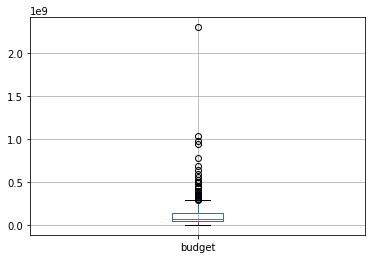

In [56]:
# Импорт библиотеки matplotlib для работы с графиками.
import matplotlib.pyplot as plt
# Построение диаграммы размаха
movies.boxplot(column=['budget'])
plt.show()

**Среднее значение выше медианного в 2 раза, что говорит о наличии явных выбросов, которые влияют на статистику. Что подтверждает диаграмма размаха.**

**Отфильтруем выбросы с учетом межквартального размаха.**

In [57]:
# Вычисление выбросов в колонке бюджета, с учетом межквартильного размаха
q1 = movies['budget'].quantile(0.25)
q3 = movies['budget'].quantile(0.75)
iqr = q3 - q1
movies_budget_anomal = movies.query('budget > (@q3 + 1.5*@iqr)  or  budget < (@q1 - 1.5*@iqr)')
print('Количество выбросов в колонке "бюджет":', len(movies_budget_anomal))

Количество выбросов в колонке "бюджет": 32


In [58]:
print('Доля потери данных:', round((len(movies_budget_anomal))/movies['budget'].count(),2))

Доля потери данных: 0.1


**10 % потери данных уже на грани, потеря данных более 10% может повлиять на статистику.**

**А также при удалении данных в колонке с бюджетом мы можем потерять важные данные в колонках с гос. финансированием, а именно refundable_support и nonrefundable_support.**

**Исследуем по-отдельности выбросы в данных колонках, выведем пересечения в выбросах по всем трём колонкам budget, refundable_support и nonrefundable_support.**

In [59]:
# Выведем основную статистику по столбцу "возвратные средства гос. поддержки"
movies['refundable_support'].describe()

count         332.00
mean     11864457.83
std      24916555.26
min             0.00
25%             0.00
50%             0.00
75%      15000000.00
max     180000000.00
Name: refundable_support, dtype: float64

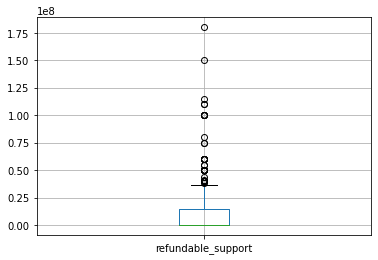

In [60]:
# Построение диаграммы размаха
movies.boxplot(column=['refundable_support'])
plt.show()

In [61]:
# Вычисление выбросов в колонке возвратных средств, с учетом межквартильного размаха
q1 = movies['refundable_support'].quantile(0.25)
q3 = movies['refundable_support'].quantile(0.75)
iqr = q3 - q1
movies_refundable_anomal = movies.query('refundable_support > (@q3 + 1.5*@iqr)  or  refundable_support < (@q1 - 1.5*@iqr)')
print('Количество выбросов в колонке "возвратные средства гос. поддержки":', len(movies_refundable_anomal))

Количество выбросов в колонке "возвратные средства гос. поддержки": 40


In [62]:
print('Доля потери данных:', round((len(movies_refundable_anomal))/movies['budget'].count(),2))

Доля потери данных: 0.12


In [63]:
# Выведем основную статистику по столбцу "невозвратные средства гос. поддержки"
movies['nonrefundable_support'].describe()

count         332.00
mean     48980988.89
std      59980117.92
min             0.00
25%      25000000.00
50%      30000000.00
75%      40375000.00
max     400000000.00
Name: nonrefundable_support, dtype: float64

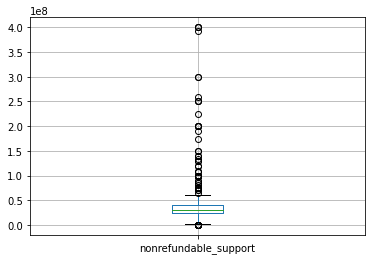

In [64]:
# Построение диаграммы размаха
movies.boxplot(column=['nonrefundable_support'])
plt.show()

In [65]:
# Вычисление выбросов в колонке невозвратных средств, с учетом межквартильного размаха
q1 = movies['nonrefundable_support'].quantile(0.25)
q3 = movies['nonrefundable_support'].quantile(0.75)
iqr = q3 - q1
movies_nonrefundable_anomal = movies.query('nonrefundable_support > (@q3 + 1.5*@iqr)  or  nonrefundable_support < (@q1 - 1.5*@iqr)')
print('Количество выбросов в колонке "возвратные средства гос. поддержки":', len(movies_nonrefundable_anomal))

Количество выбросов в колонке "возвратные средства гос. поддержки": 57


In [66]:
print('Доля потери данных:', round((len(movies_nonrefundable_anomal))/movies['budget'].count(),2))

Доля потери данных: 0.17


In [67]:
# Сформируем сводную таблицу по выбросам колонки возвратных средств
movies_refundable_anomal = movies_refundable_anomal.pivot_table(index= 'pu_number',values='refundable_support', aggfunc='count')
movies_refundable_anomal.reset_index().head()

,pu_number,refundable_support
0,111000416,1
1,111000717,1
2,111001118,1
3,111001317,1
4,111001517,1


In [68]:
# Сформируем сводную таблицу по выбросам колонки возвратных средств
movies_nonrefundable_anomal = movies_nonrefundable_anomal.pivot_table(index= 'pu_number',values='nonrefundable_support', aggfunc='count')
movies_nonrefundable_anomal.reset_index().head()

,pu_number,nonrefundable_support
0,111000415,1
1,111000419,1
2,111000717,1
3,111001317,1
4,111001517,1


In [69]:
# Сформируем сводную таблицу по выбросам колонки с бюджетом
movies_budget_anomal = movies_budget_anomal.pivot_table(index= 'pu_number',values='budget', aggfunc='count')
movies_budget_anomal.reset_index().head()

,pu_number,budget
0,111000515,1
1,111000715,1
2,111000717,1
3,111001317,1
4,111002419,1


In [70]:
# Сформируем список пересечений выбросов по колнкам возвратных и невозвратных средств
movies_fundable_anomal = movies_nonrefundable_anomal.merge(movies_refundable_anomal, on='pu_number',how='inner')

In [71]:
# А теперь сформируем список пересечений выбросов с колонкой "бюджет"
movies_budget_anomal_good = movies_budget_anomal.merge(movies_fundable_anomal, on='pu_number',how='inner')
movies_budget_anomal_good

,budget,nonrefundable_support,refundable_support
pu_number,,,
111000717,1,1,1
111001317,1,1,1
111005416,1,1,1
111005717,1,1,1
111007617,1,1,1
111012819,1,1,1
111015416,1,1,1
111016316,1,1,1
111022019,1,1,1


In [72]:
print('Доля потери данных:', round((len(movies_budget_anomal_good))/movies['budget'].count(),2))

Доля потери данных: 0.04


**Мы получили список пересечений выбросов по трем колонкам, что составило 4% от данных. Соответвенно, эти выбросы можно удалить без потери важных данных.**

In [73]:
# Перезаписываем датафрейм , исключив найденные выбросы.
movies = movies.query('pu_number not in @movies_budget_anomal_good.index')
# Упорядочиваем индексы
movies.reset_index(drop=True).tail()

,pu_number,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,ratings_nan,genres_nan
7468,126008019,Сад художника: Американский импрессионизм,2019-12-23,Прочие,Севен Артс Продакшнз,Великобритания,Фил Грабски,Фил Грабски,«12+» - для детей старше 12 лет,<NA>,<NA>,<NA>,без поддержки,NaN,не определено,NaN,True,True
7469,121037819,Звериная ярость,2019-12-24,Художественный,"Дэниел Гродник Продакшнз, Вандерфилм Медиа Кор...",США,Ник Пауэлл,"Джефф Боулер, Дэниэл Гродник, Луильо Руис, Брэ...",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,5.40,"боевик,триллер",NaN,False,False
7470,124010819,Щенячий патруль: Скорей спешим на помощь!,2019-12-28,Художественный,"Никелодеон Анимейшн Студиос, Спин Мастер",США - Канада,Чарльз Е.Бастьен,Дженнифер Додж,«0+» - для любой зрительской аудитории,<NA>,<NA>,<NA>,без поддержки,NaN,не определено,NaN,True,True
7471,124010619,"Машины песенки. Серия ""Испанские мотивы""",2019-12-30,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",А.Беляев,Д.Ловейко,«0+» - для любой зрительской аудитории,<NA>,<NA>,<NA>,без поддержки,NaN,не определено,NaN,True,True
7472,124010719,"Машины песенки. Серия ""Когда цветут кактусы""",2019-12-30,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",И.Трусов,Д.Ловейко,«0+» - для любой зрительской аудитории,<NA>,<NA>,<NA>,без поддержки,6.30,"комедия,вестерн",NaN,False,False


Рассмотрим ещё раз колонки с бюджетом и финансированием , уже с очищенными данными.

In [74]:
# Выведем основную статистику
movies[movies['budget']>0]['budget'].describe()

count         303.00
mean    108627902.37
std     102481457.13
min      14462464.00
25%      45278890.00
50%      69883049.00
75%     137278035.50
max     779941965.00
Name: budget, dtype: float64

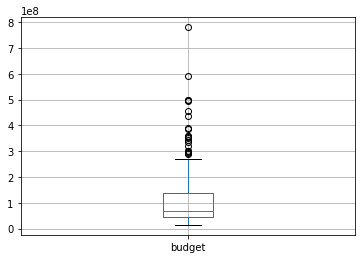

In [75]:
# Построение диаграммы размаха с очищенными данными
movies[movies['budget']>0].boxplot(column=['budget'])
plt.show()

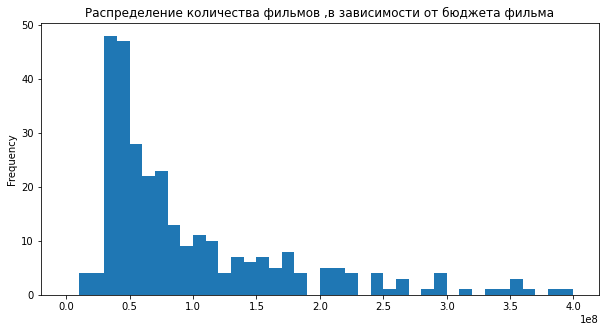

In [76]:
# Построение гистограммы с очищенными данными
movies['budget'].plot(
    kind ='hist',
    bins=40,
    range =(1,400000000),
    figsize = (10,5),
    title = 'Распределение количества фильмов ,в зависимости от бюджета фильма'
)
plt.show()

**Больше всего финансируемых государством фильмов встречается с бюджетом от 45 млн. до 70 млн. руб.**

In [77]:
# Выведем основную статистику
movies[movies['refundable_support']>0]['refundable_support'].describe()

count          99.00
mean     28525252.53
std      22326446.44
min       3500000.00
25%      12500000.00
50%      25000000.00
75%      40000000.00
max     115000000.00
Name: refundable_support, dtype: float64

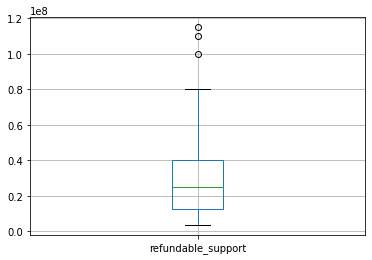

In [78]:
# Построение диаграммы размаха
movies[movies['refundable_support']>0].boxplot(column=['refundable_support'])
plt.show()

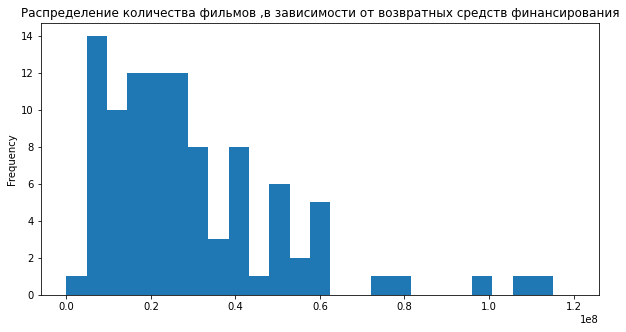

In [79]:
# Построение гистограммы с очищенными данными
movies['refundable_support'].plot(
    kind ='hist',
    bins=25,
    range =(1,120000000),
    figsize = (10,5),
    title = 'Распределение количества фильмов ,в зависимости от возвратных средств финансирования'
)
plt.show()

**Чаще всего сумма возвратных средств составляет от 5 млн. до 30 млн. руб.**

In [80]:
# Выведем основную статистику
movies[movies['nonrefundable_support']>0]['nonrefundable_support'].describe()

count         312.00
mean     43572384.07
std      44541415.99
min       3000000.00
25%      25000000.00
50%      30000000.00
75%      40000000.00
max     400000000.00
Name: nonrefundable_support, dtype: float64

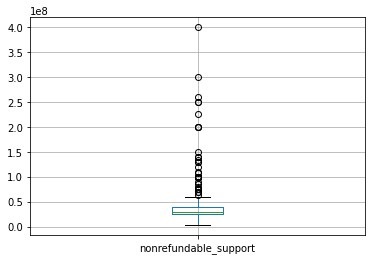

In [81]:
# Построение диаграммы размаха
movies[movies['nonrefundable_support']>0].boxplot(column=['nonrefundable_support'])
plt.show()

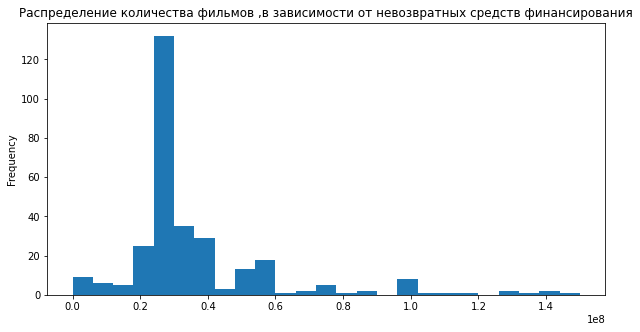

In [82]:
# Построение гистограммы с очищенными данными
movies['nonrefundable_support'].plot(
    kind ='hist',
    bins=25,
    range =(1,150000000),
    figsize = (10,5),
    title = 'Распределение количества фильмов ,в зависимости от невозвратных средств финансирования'
)
plt.show()

**Самая популярная сумма невозвратных средств со стороны гос. финансирования  - это 30 млн . руб.**

**Проанализируем колонку с рейтингами фильмов.**

In [83]:
# Выведем основную статистику по колонке "рейтинг фильма".
movies['ratings'].describe()

count   6507.00
mean       6.49
std        1.11
min        1.00
25%        5.90
50%        6.60
75%        7.20
max        9.90
Name: ratings, dtype: float64

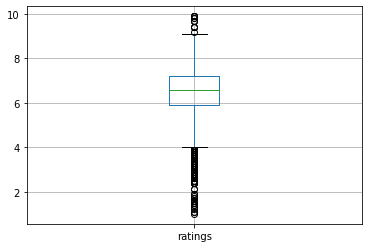

In [84]:
# Построение диаграммы размаха
movies.boxplot(column=['ratings'])
plt.show()

**По диаграмме размаха видно, что есть выбросы как в низком, так и в высокой рейтинге фильмов.**

**Вычислим количество выбросов.**

In [85]:
# Вычисление выбросов в колонке невозвратных средств, с учетом межквартильного размаха
q1 = movies['ratings'].quantile(0.25)
q3 = movies['ratings'].quantile(0.75)
iqr = q3 - q1
movies_ratings_anomal = movies.query('ratings > (@q3 + 1.5*@iqr)  or  ratings < (@q1 - 1.5*@iqr)')
print('Количество выбросов в колонке "рейтинг":', len(movies_ratings_anomal))

Количество выбросов в колонке "рейтинг": 192


In [86]:
print('Доля потери данных:', round((len(movies_ratings_anomal))/movies['ratings'].count(),2))

Доля потери данных: 0.03


**Доля потери данных не высокая, однако мы не можем удалить данные , где есть информация по финансированию фильмов, поэтому удалим только те выбросы, которые не затрагивают данную информацию.**

In [87]:
# Сформируем список выбросов рейтингов по номерам удостоверений
movies_ratings_anomal_good = movies_ratings_anomal.pivot_table(index = 'pu_number', values = 'title', aggfunc='count')

In [88]:
# Сформируем список номеров удостоверений с данными о финансировании.
movies_filter_fundable= movies.query('refundable_support > 0 or nonrefundable_support >0 or budget > 0 ').pivot_table(index='pu_number', values = 'title', aggfunc = 'count')

In [89]:
# Отфильтруем список выбросов рейтингов, исключив данные с финансированием
movies_ratings_anomal_good = movies_ratings_anomal_good.query('pu_number not in @movies_filter_fundable.index')

In [90]:
# Перезаписываем датафрейм.
movies = movies.query('pu_number not in @movies_ratings_anomal_good.index')
# Упорядочиваем индексы
movies.reset_index(drop=True).tail()

,pu_number,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,ratings_nan,genres_nan
7292,126008019,Сад художника: Американский импрессионизм,2019-12-23,Прочие,Севен Артс Продакшнз,Великобритания,Фил Грабски,Фил Грабски,«12+» - для детей старше 12 лет,<NA>,<NA>,<NA>,без поддержки,NaN,не определено,NaN,True,True
7293,121037819,Звериная ярость,2019-12-24,Художественный,"Дэниел Гродник Продакшнз, Вандерфилм Медиа Кор...",США,Ник Пауэлл,"Джефф Боулер, Дэниэл Гродник, Луильо Руис, Брэ...",«16+» - для детей старше 16 лет,<NA>,<NA>,<NA>,без поддержки,5.40,"боевик,триллер",NaN,False,False
7294,124010819,Щенячий патруль: Скорей спешим на помощь!,2019-12-28,Художественный,"Никелодеон Анимейшн Студиос, Спин Мастер",США - Канада,Чарльз Е.Бастьен,Дженнифер Додж,«0+» - для любой зрительской аудитории,<NA>,<NA>,<NA>,без поддержки,NaN,не определено,NaN,True,True
7295,124010619,"Машины песенки. Серия ""Испанские мотивы""",2019-12-30,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",А.Беляев,Д.Ловейко,«0+» - для любой зрительской аудитории,<NA>,<NA>,<NA>,без поддержки,NaN,не определено,NaN,True,True
7296,124010719,"Машины песенки. Серия ""Когда цветут кактусы""",2019-12-30,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",И.Трусов,Д.Ловейко,«0+» - для любой зрительской аудитории,<NA>,<NA>,<NA>,без поддержки,6.30,"комедия,вестерн",NaN,False,False


In [91]:
movies['ratings'].describe()

count   6331.00
mean       6.57
std        0.98
min        1.00
25%        5.90
50%        6.60
75%        7.30
max        9.40
Name: ratings, dtype: float64

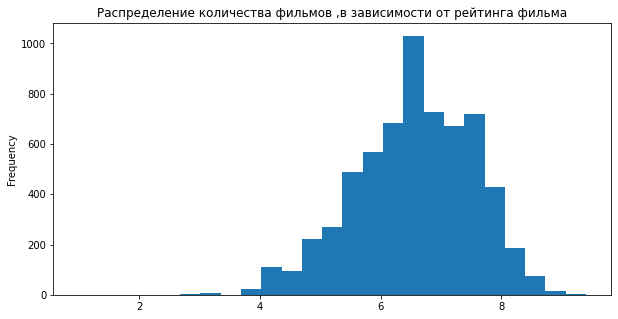

In [92]:
# Построим финальную гистограмму с очищенными данными
movies['ratings'].plot(
    kind ='hist',
    bins=25,
    figsize = (10,5),
    title = 'Распределение количества фильмов ,в зависимости от рейтинга фильма'
)
plt.show()

**Больше всего фильмов с рейтингом от 6,5 - 7,0**

**Проанализируем колонку со сборами в прокате.**

In [93]:
# Выведем основную статистику по колонке "сумма сборов в прокате".
movies['box_office'].describe()

count         3061.00
mean      76163900.21
std      238461006.18
min              0.00
25%         103210.00
50%        2428366.00
75%       24294621.52
max     3073568690.79
Name: box_office, dtype: float64

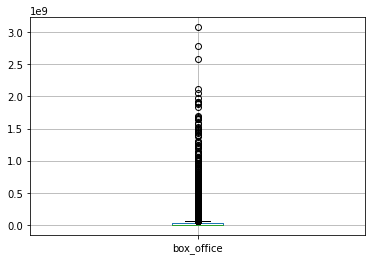

In [94]:
# Построение диаграммы размаха
movies.boxplot(column=['box_office'])
plt.show()

**Среднее значение выше в несколько десятков раз, чем медианное значение, это говорит, о серьёзной разрозненности в данных. На диаграмме размаха видно большое количество выбросов.**

In [95]:
# Вычисление выбросов в колонке сборы с прокатов, с учетом межквартильного размаха
q1 = movies['box_office'].quantile(0.25)
q3 = movies['box_office'].quantile(0.75)
iqr = q3 - q1
box_office_anomal = movies.query('box_office > (@q3 + 1.5*@iqr)  or  box_office < (@q1 - 1.5*@iqr)')
print('Количество выбросов в колонке "сборы в прокате":', len(box_office_anomal))

Количество выбросов в колонке "сборы в прокате": 529


In [96]:
print('Процент потери данных:', round((len(box_office_anomal))/movies['box_office'].count(),2))

Процент потери данных: 0.17


**Процент выбросов от общей массы известных данных по сборам 17%, это очень большой процент. Возможно часть данных записаны в рублях, а какие -то данные в тысячах.** 

**Выявить закономерности с такими данными будет сложно.**

**Проверим данные по сборам в рамках финансируемых фильмов.**

In [97]:
# Формирование среза по финансируемым фильмам
box_office_good = movies.query('box_office > 0 and (budget > 0 or  refundable_support > 0 or nonrefundable_support > 0)')
len(box_office_good)

307

In [98]:
# Выведем основную статистику 
box_office_good['box_office'].describe()

count          307.00
mean     113057323.32
std      303647894.22
min           1550.00
25%        1146791.00
50%       12748398.30
75%       95995289.06
max     3073568690.79
Name: box_office, dtype: float64

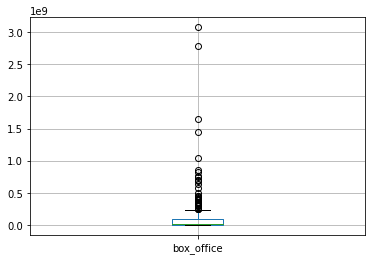

In [99]:
# Построение диаграммы размаха
box_office_good.boxplot(column=['box_office'])
plt.show()

Средняя и медиана стали ближе, но всё равно между ними  разрыв в несколько раз.

In [100]:
# Вычисление выбросов в колонке сборы с прокатов, с учетом межквартильного размаха
q1 = box_office_good['box_office'].quantile(0.25)
q3 = box_office_good['box_office'].quantile(0.75)
iqr = q3 - q1
box_office_anomal_filter = box_office_good.query('box_office > (@q3 + 1.5*@iqr)  or  box_office < (@q1 - 1.5*@iqr)')
len(box_office_anomal_filter)

39

In [101]:
print('Процент потери данных:', round((len(box_office_anomal_filter))/len(box_office_good),2))

Процент потери данных: 0.13


In [102]:
box_office_anomal_filter

,pu_number,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,ratings_nan,genres_nan
1869,111002915,А зори здесь тихие..._,2015-03-16,Художественный,"ООО ""Компания ""Реал-Дакота""",Россия,Р.Давлетьяров,не определено,«12+» - для детей старше 12 лет,50000000,100000000,220588394,Фонд кино,8.50,"драма,военный,история",249166767.70,False,False
1902,111001815,Призрак_.,2015-03-02,Художественный,"ООО ""Водород 2011""",Россия,А.Войтинский,С.Сельянов,«6+» - для детей старше 6 лет,0,75000000,139551503,Фонд кино,7.00,"триллер,боевик,приключения",352804320.40,False,False
2004,114000214,Снежная Королева 2: Перезаморозка,2014-11-13,Анимационный,"ООО ""ВИЗАРТ ФИЛЬМ""",Россия,А.Цицилин,"ООО ""ВИЗАРТ ФИЛЬМ"", ООО ""ТаББаК""",«0+» - для любой зрительской аудитории,30000000,40000000,252489571,Фонд кино,6.50,"мультфильм,фэнтези,приключения",313489846.50,False,False
2057,111000415,Дуxless 2,2015-01-26,Художественный,"ООО ""Киностудия ""Слово"", ООО ""Арт Пикчерс Студия""",Россия,Р.Прыгунов,"П.Ануров, Ф.Бондарчук, Д.Рудовский",«16+» - для детей старше 16 лет,0,75000000,0,Фонд кино,6.60,драма,446163511.00,False,False
2091,111000715,Батальонъ,2015-01-29,Художественный,"ООО ""Корнер Ворк"", ООО ""Арт Пикчерс Студия""",Россия,Д.Месхиев,И.Угольников,«12+» - для детей старше 12 лет,0,56579055,436437176,"Министерство культуры, Фонд кино",7.10,"драма,военный,история",451812221.70,False,False
2131,111001415,Битва за Севастополь,2015-02-20,Художественный,"ООО ""Кинокомпания ""Новые люди"", ООО ""Студия ""К...",Россия-Украина,С.Мокрицкий,"Н.Мокрицкая, Е.Олесов",«12+» - для детей старше 12 лет,0,27510000,131000000,Министерство культуры,7.50,"биография,военный,драма",401804461.90,False,False
2204,111014914,8 новых свиданий,2014-10-30,Художественный,"ООО ""Смарт ТВ Продакшн""",Россия,М.Бальчюнас,"ООО ""Грин Филмс"", ООО ""ПЦ ""Горад""",«12+» - для детей старше 12 лет,0,30000000,77401751,Фонд кино,6.00,комедия,393344626.30,False,False
2573,114002815,Смешарики. Легенда о золотом драконе,2015-10-07,Анимационный,"ООО ""Смешарики""",Россия,Д.Чернов,"И.Попов, Ф.Бондарчук, Д.Рудовский",«6+» - для детей старше 6 лет,40000000,110000000,240153900,Фонд кино,6.30,"мультфильм,приключения,комедия",242403434.60,False,False
2700,111017815,Самый Лучший День,2015-10-14,Художественный,"ООО ""ТаББаК""",Россия,А.Першин (псевдоним Ж.Крыжовников),"Т.Бекмамбетов, А.Першин (псевдоним Ж.Крыжовник...",«16+» - для детей старше 16 лет,29000000,34000000,130619336,Фонд кино,4.70,"комедия,музыка",683029061.40,False,False
2766,111018415,Страна чудес,2015-10-16,Художественный,"ООО ""Ол Медиа Компани""",Россия,Д.Дьяченко,"Г.Шабанов, Р.Татаринцев, Э.Илоян",«12+» - для детей старше 12 лет,41000000,25000000,105445546,Фонд кино,6.00,"ужасы,комедия",294590750.60,False,False


**Процент выбросов в рамках финансируемых фильмов тоже большой, но удалять данные нельзя, чтобы не потерять другие важные данные.**

### Добавление новых столбцов




In [103]:
# Создаем новую колонку с указанием года премьеры
movies['year_show'] = movies['show_start_date'].dt.year

In [104]:
# Создаем новую колонку с первым жанром
movies['genres_first'] = movies['genres'].str.split(',').str[0]

In [105]:
# Создаем новую колонку с именем первого режиссера
movies['director_first'] = movies['director'].str.split(',').str[0]

In [106]:
movies.head(4)

,pu_number,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,...,budget,financing_source,ratings,genres,box_office,ratings_nan,genres_nan,year_show,genres_first,director_first
0,221048915,Открытый простор,2015-11-27,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,<NA>,...,<NA>,без поддержки,7.20,"боевик,драма,мелодрама",NaN,False,False,2015,боевик,Кевин Костнер
1,111013716,Особо важное задание,2016-09-13,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,не определено,«6+» - для детей старше 6 лет,<NA>,...,<NA>,без поддержки,6.60,"драма,военный",NaN,False,False,2016,драма,Е.Матвеев
2,221038416,Особо опасен,2016-10-10,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,<NA>,...,<NA>,без поддержки,6.80,"фантастика,боевик,триллер",NaN,False,False,2016,фантастика,Тимур Бекмамбетов
3,221026916,Особо опасен,2016-06-10,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,<NA>,...,<NA>,без поддержки,6.80,"фантастика,боевик,триллер",NaN,False,False,2016,фантастика,Тимур Бекмамбетов


- Посчитайте, какую долю от общего бюджета фильма составляет государственная поддержка.

In [107]:
# Создаем новую колонку с общим бюджетом финансирования
movies['fundable_total'] = movies['refundable_support'] + movies['nonrefundable_support']

In [108]:
# Вычисляем долю от общего бюджета фильма.
movies['fundable_part'] = movies['fundable_total']/movies['budget']

## Исследовательский анализ данных. Анализ фильмов , вышедших в прокат


### Кол-во фильмов, вышедших в прокат в динамике по годам

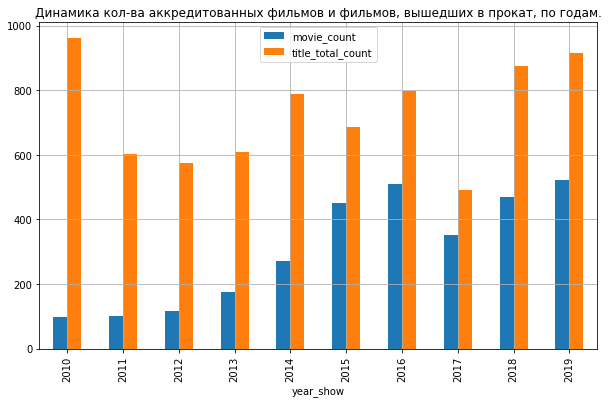

In [109]:
# Формируем сводную таблицу с общим количеством аккредитованных фильмов и фильмов в прокате, по годам.
film_rental = movies.pivot_table(index = 'year_show', values = ['title','box_office' ], aggfunc =['count','sum','median','mean'])
film_rental.columns = ['movie_count','title_total_count','box_office_sum','box_office_median','box_office_mean']
film_rental.plot(
    kind ='bar',
    grid=True,
    y=['movie_count','title_total_count'],
    figsize=(10,6),
    title = 'Динамика кол-ва аккредитованных фильмов и фильмов, вышедших в прокат, по годам.')
plt.show()

### Изменение доли кол-ва фильмов в прокате в отношении аккредитованных фильмов

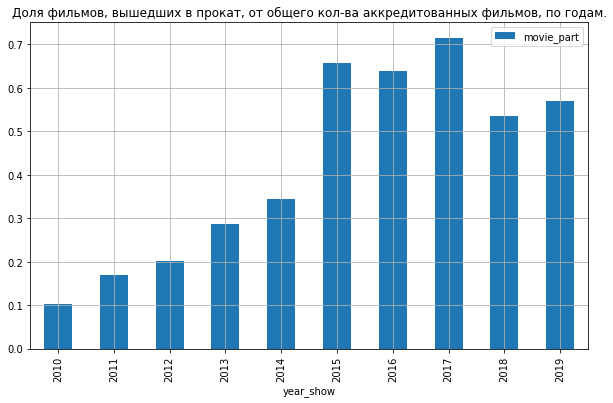

In [110]:
# Создаем новую колонку с долей фильмов в прокате от общего кол-ва аккредитованных фильмов
film_rental['movie_part'] = film_rental['movie_count']/film_rental['title_total_count']
film_rental.plot(
    y = 'movie_part',
    kind ='bar',
    grid=True,
    figsize=(10,6),
    title = 'Доля фильмов, вышедших в прокат, от общего кол-ва аккредитованных фильмов, по годам.')
plt.show()

**с 2010 по 2019 год в год аккредитовалось от 500 до 1000 фильмов, но данные о прокате фильмов более полные начинаются с 2015 года, самая полная информация по прокатам фильмов в 2015-2017 годах, а именно, по порядку 65%, 63%, 71% от кол-ва аккретованных фильмов. В  2018 году доля вышедших в прокат резко упала до 54% от всех аккредитованных фильмов.**

**Посмотрим, что это за фильмы.**

### Изучение типов фильмов аккредитованных и в прокате

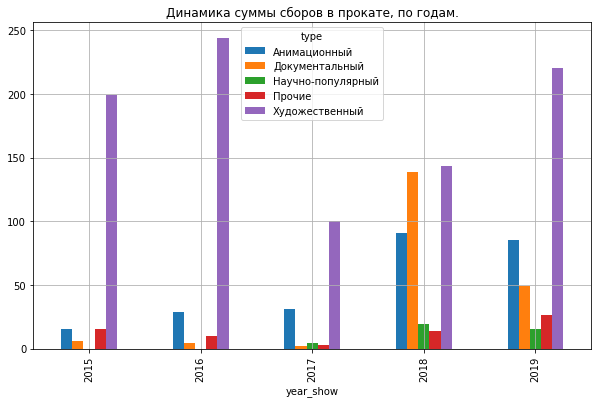

In [111]:
(
    movies.query('box_office.isna() and year_show > 2014')
    .pivot_table(index ='year_show',columns = 'type', values = 'title', aggfunc ='count')
    .plot(kind ='bar', grid=True, figsize=(10,6), title = 'Динамика суммы сборов в прокате, по годам.')
)
plt.show()

По диаграмме видно, что в 2015 -2017 годах было больше всего аккредитованных фильмов типа Художественный, а  в 2018 и 2019 гг. резко увеличилось кол-во Документальных и Анимационных фильмов. Скорее всего эти фильмы не предназначены для показа в кинотеатрах, а предназначены для показов на ТВ.

In [112]:
# Выведем список Документальных и Анимационных фильмов в 2018-2019 гг.
movies.query(
'box_office.isna() and (year_show == 2018 or year_show == 2019) and (type=="Документальный" or type=="Анимационный")')

,pu_number,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,...,ratings,genres,box_office,ratings_nan,genres_nan,year_show,genres_first,director_first,fundable_total,fundable_part
5661,114003417,МУЛЬТ в кино. Выпуск № 66,2018-01-04,Анимационный,"ООО ""Мульт в кино""",Россия,О.Семёнова,П.Смирнов,«0+» - для любой зрительской аудитории,<NA>,...,NaN,не определено,NaN,True,True,2018,не определено,О.Семёнова,<NA>,<NA>
5722,114000318,МУЛЬТ в кино. Выпуск № 69,2018-02-17,Анимационный,"ООО ""Мульт в кино""",Россия,О.Семёнова,П.Смирнов,«0+» - для любой зрительской аудитории,<NA>,...,NaN,не определено,NaN,True,True,2018,не определено,О.Семёнова,<NA>,<NA>
5738,114000418,МУЛЬТ в кино. Выпуск № 70,2018-03-03,Анимационный,"ООО ""Мульт в кино""",Россия,О.Семёнова,П.Смирнов,«0+» - для любой зрительской аудитории,<NA>,...,NaN,не определено,NaN,True,True,2018,не определено,О.Семёнова,<NA>,<NA>
5743,124000518,"Маша и Медведь. Серия ""Квартет плюс""",2018-02-28,Анимационный,Анимаккорд Лтд,Республика Кипр,Андрей Беляев,"Олег Кузовков, Дмитрий Ловейко, Марина Ратина",«0+» - для любой зрительской аудитории,<NA>,...,NaN,не определено,NaN,True,True,2018,не определено,Андрей Беляев,<NA>,<NA>
5768,114000718,МУЛЬТ в кино. Выпуск № 71,2018-03-17,Анимационный,"ООО ""Мульт в кино""",Россия,О.Семёнова,П.Смирнов,«0+» - для любой зрительской аудитории,<NA>,...,NaN,не определено,NaN,True,True,2018,не определено,О.Семёнова,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7461,114004919,МУЛЬТ в кино. Выпуск № 109,2019-12-21,Анимационный,"ООО ""Мульт в кино""",Россия,П.Смирнов,П.Смирнов,«0+» - для любой зрительской аудитории,<NA>,...,NaN,не определено,NaN,True,True,2019,не определено,П.Смирнов,<NA>,<NA>
7469,112004819,Дикие и свободные,2019-12-23,Документальный,"АНО ""ТВ-Новости""",Россия,Н.Карачкова,В.Сенина,«6+» - для детей старше 6 лет,<NA>,...,NaN,не определено,NaN,True,True,2019,не определено,Н.Карачкова,<NA>,<NA>
7472,124010519,Ходячий замок,2019-12-19,Анимационный,"Студио Гибли, Буена Виста Хоум Интертейнмент, ...",Япония,Хаяо Миядзаки,"Томохико Исии, Хаяо Миядзаки, Тосио Судзуки",«6+» - для детей старше 6 лет,<NA>,...,8.30,"аниме,мультфильм,фэнтези",NaN,False,False,2019,аниме,Хаяо Миядзаки,<NA>,<NA>
7483,124010619,"Машины песенки. Серия ""Испанские мотивы""",2019-12-30,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",А.Беляев,Д.Ловейко,«0+» - для любой зрительской аудитории,<NA>,...,NaN,не определено,NaN,True,True,2019,не определено,А.Беляев,<NA>,<NA>


**Гипотеза подтвердилась, в 2018 -2019 году вышло много фильмов , сериального формата, мультики для самых маленьких или просто формата для показа на ТВ.**

### Динамика проката по годам. Максимальная и минимальная сумма сборов.

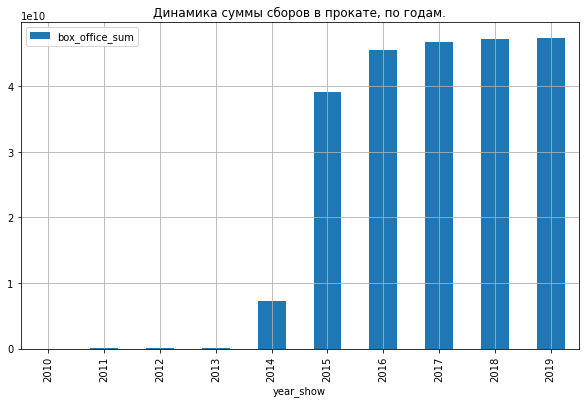

In [113]:
film_rental.plot(
    y = 'box_office_sum',
    kind ='bar',
    grid=True,
    figsize=(10,6),
    title = 'Динамика суммы сборов в прокате, по годам.')
plt.show()

**Если считать, что до 2015 года недосточно данных, то в 2015 году была самая маленькая сумма проката, 39 000 млн. руб. И далее с каждым годом сумма проката росла, в 2019 году сумма проката выросла до 48 000 млн. руб.**

- С помощью сводной таблицы посчитайте среднюю и медианную сумму сборов для каждого года.

**Из выше созданной сводной таблицы выведем на график показатели медианных и средних значений проката по годам.**

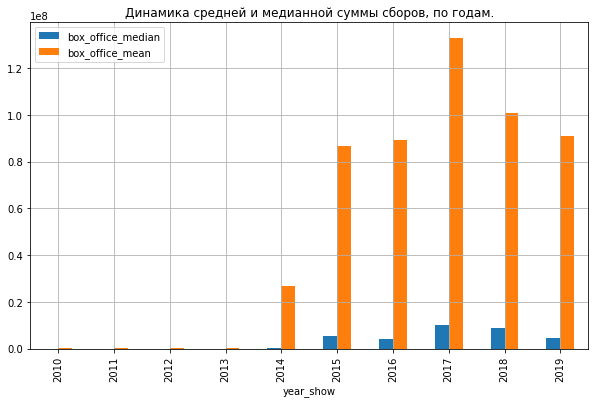

In [157]:
film_rental.plot(kind ='bar',  grid=True, y=['box_office_median','box_office_mean'],figsize=(10,6), title = 'Динамика средней и медианной суммы сборов, по годам.')
plt.show()

**С 2015 года по графику мы видим, что самая распространенная сумма сборов с одного фильма, в динамике по годам, является от 5 до 10 млн. руб. Однако средняя сумма сборов свидетельсвует о том, что каждый год выходило в прокат несколько супер-успешных фильмов, которые собрали в десятки раз больше сборов - это и повлияло на значительную разницу в медианной и средней сумме сборов. Можно предположить, что рынок проката обладает большим потенциалом, но весьма специфическим. Проекты могут выстреливать до "огромных" сумм сборов.**

### Изучение возрастного ограничения аудитории («6+», «12+», «16+», «18+» и т. д.) на сборы фильма в прокате в период с 2015 по 2019 год

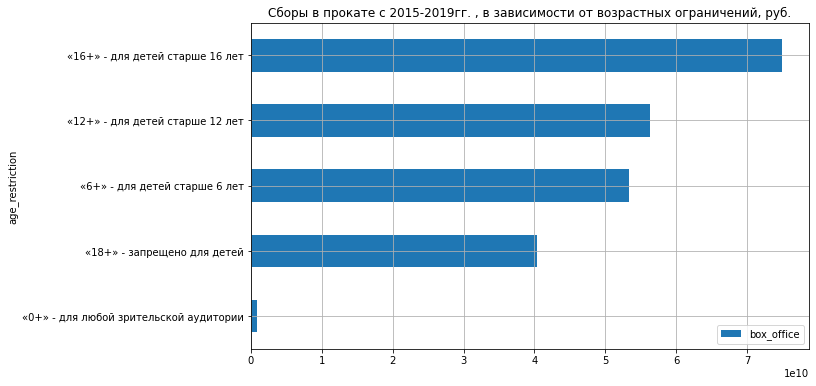

In [115]:
# Сформируем сводную таблицу по сумме сборов , в зависимости от возрастных ограничений и выведем график.
(
    movies[movies['year_show'] >2014]
    .pivot_table(index='age_restriction', values = 'box_office', aggfunc = 'sum')
    .sort_values(by='box_office')
    .plot(kind ='barh',
          grid=True,
          y='box_office',
          figsize=(10,6),
          title = 'Сборы в прокате с 2015-2019гг. , в зависимости от возрастных ограничений, руб.')
)
plt.show()

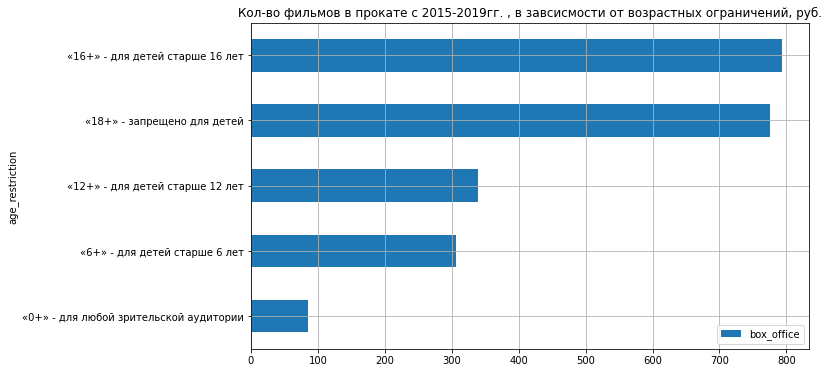

In [116]:
# Сформируем сводную таблицу по кол-ву фильмов в прокате , в зависимости от возрастных ограничений и выведем график.
(
    movies[movies['year_show'] >2014]
    .pivot_table(index='age_restriction', values = 'box_office', aggfunc = 'count')
    .sort_values(by='box_office')
    .plot(kind ='barh',
          grid=True,
          y='box_office',
          figsize=(10,6),
          title = 'Кол-во фильмов в прокате с 2015-2019гг. , в завсисмости от возрастных ограничений, руб.')
)
plt.show()

**Больше всего собрали в прокате с 2015 по 2019 годы фильмы 16+, на втором месте  12+. При этом больше всего фильмов вышло в прокат 16+ и 18+.**

**Посмотрим на динамику по годам.**

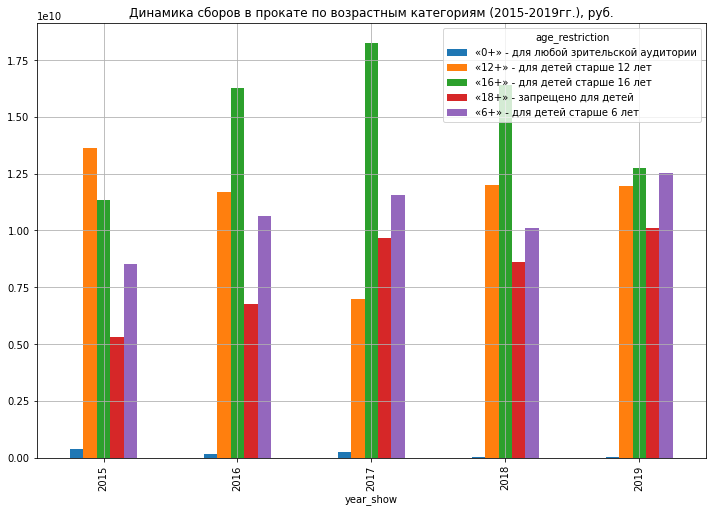

In [117]:
# Сформируем сводную таблицу по сумме сборов по годам , в зависимости от возрастных ограничений и выведем график.
(
movies.query('year_show > 2014 and box_office >=0' )
    .pivot_table(index='year_show', columns ='age_restriction', values = 'box_office', aggfunc = 'sum')
    .plot(kind ='bar',
          grid=True,
          figsize=(12,8),
          title = 'Динамика сборов в прокате по возрастным категориям (2015-2019гг.), руб.')
)
plt.show()

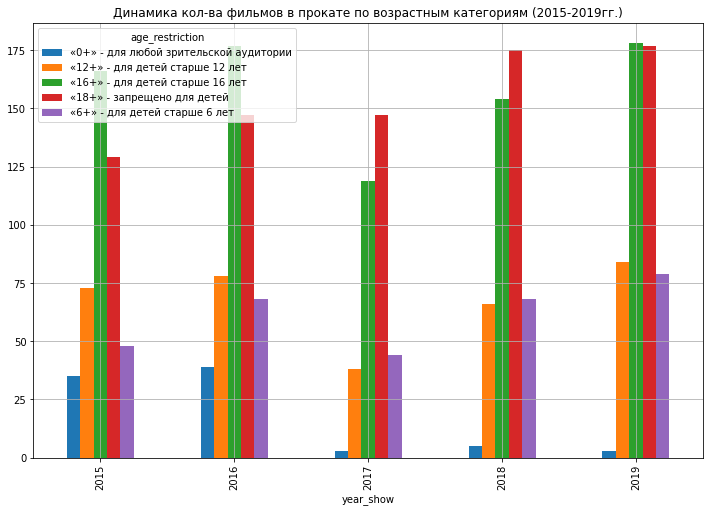

In [118]:
# Сформируем сводную таблицу по кол-ву фильмов в прокате  по годам , в зависимости от возрастных ограничений и выведем график.
(
    movies.query('year_show > 2014 and box_office >=0' )
    .pivot_table(index='year_show', columns ='age_restriction', values = 'box_office', aggfunc = 'count')
    .plot(kind ='bar',
          grid=True,
          figsize=(12,8),
          title = 'Динамика кол-ва фильмов в прокате по возрастным категориям (2015-2019гг.)')
)
plt.show()

**Аналогичная ситуация, больше всего сборов по годам собирают фильмы 16+, только в 2015 году больше всего сборов было в категории 12+. В 2015 году вышла очередная часть культового "Человека-паука", которая безусловно повлияла на сумму сборов в категории 12+.**

**Однако по кол-ву фильмов в прокате больше от года к году превалирует то у возрастного ограничения 18+, то у 16+.** 

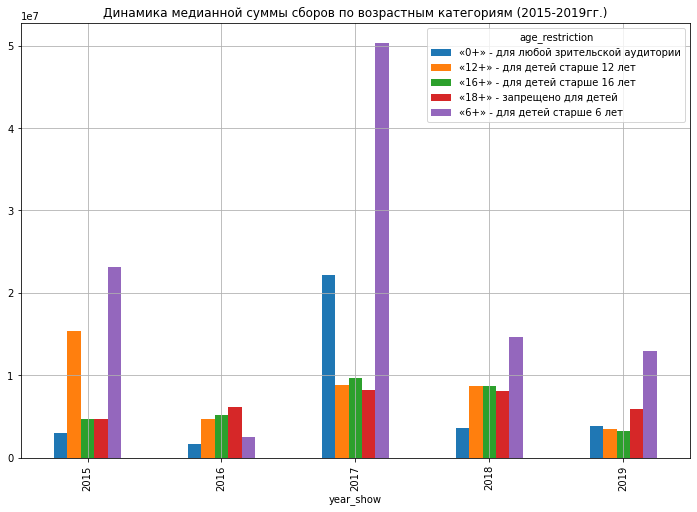

In [119]:
# Сформируем сводную таблицу по медианой сумме сборов  по годам , в зависимости от возрастных ограничений и выведем график.
(
    movies.query('year_show > 2014 and box_office >=0' )
    .pivot_table(index='year_show', columns ='age_restriction', values = 'box_office', aggfunc = 'median')
    .plot(kind ='bar',
          grid=True,
          figsize=(12,8),
          title = 'Динамика медианной суммы сборов по возрастным категориям (2015-2019гг.)')
)
plt.show()

**Медианная сумма сборов выше всего у фильмов категории 6+. Однако в прокат по кол-ву фильмов  данной категории каждый год выходило в 2 раза меньше, чем категории 16+ и 18+.**
Посмотрим на топ - 5 жанров.

In [120]:
genres_top_5 = movies.query('year_show > 2014 and box_office >=0' )\
.pivot_table(index='genres_first',values = 'box_office', aggfunc = ['count','sum','median'])
genres_top_5.columns = ['count_box_office','sum_box_office','median_box_office']
genres_top_5.sort_values(by='sum_box_office', ascending=False).head()

,count_box_office,sum_box_office,median_box_office
genres_first,,,
фантастика,135,50667327834.90,137330265.84
мультфильм,200,36510403465.71,26203413.15
боевик,180,26542937645.98,29784880.83
фэнтези,95,23241742952.60,13848461.92
комедия,255,22702299597.59,8189682.18


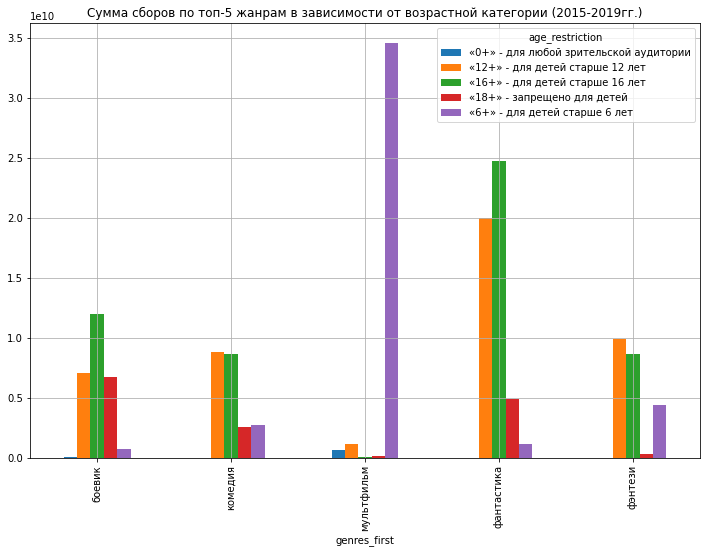

In [121]:
movies.query('year_show > 2014\
and box_office >=0\
and (genres_first=="фантастика"\
or genres_first=="мультфильм"\
or genres_first=="боевик"\
or genres_first=="фэнтези"\
or genres_first=="комедия")')\
.pivot_table(index='genres_first', columns ='age_restriction', values='box_office', aggfunc='sum')\
.plot(kind ='bar',
      grid=True,
      figsize=(12,8),
      title = 'Сумма сборов по топ-5 жанрам в зависимости от возрастной категории (2015-2019гг.)')
plt.show()

**Посмотрим на топ-20 фильмов по сумме сборов.**

In [122]:
movies.query('year_show > 2014 and box_office >=0' ).sort_values(by = 'box_office', ascending = False).head(20)

,pu_number,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,...,ratings,genres,box_office,ratings_nan,genres_nan,year_show,genres_first,director_first,fundable_total,fundable_part
7455,111021719,Холоп,2019-12-19,Художественный,"ООО ""МЕМ-МЕДИА"" по заказу АО ""ВБД Груп""",Россия,К.Шипенко,"Э.Илоян, Д.Жалинский, В.Дусмухаметов, Т.Бадзие...",«12+» - для детей старше 12 лет,25000000,...,6.80,комедия,3073568690.79,False,False,2019,комедия,К.Шипенко,60000000,0.38
5652,111011817,Движение вверх,2017-12-21,Художественный,"ООО ""Студия ""ТРИТЭ"" Никиты Михалкова""",Россия,А.Мегердичев,"Л.Верещагин, А.Златопольский, Н.Михалков, ООО ...",«6+» - для детей старше 6 лет,0,...,7.50,"спорт,драма",2779686144.00,False,False,2017,спорт,А.Мегердичев,400000000,0.68
6819,121005519,Мстители: Финал,2019-04-29,Художественный,Марвел Студиос,США,"Джо Руссо, Энтони Руссо",Кевин Фейги,«16+» - для детей старше 16 лет,<NA>,...,7.60,"фантастика,боевик,драма",2576613776.83,False,False,2019,фантастика,Джо Руссо,<NA>,<NA>
3487,121009217,Пираты Карибского моря: Мертвецы не рассказыва...,2017-05-17,Художественный,"Джерри Брукхаймер Филмз, Уолт Дисней Пикчерз, ...",США,"Йоаким Реннинг, Эспен Сандберг",Джерри Брукхаймер,«16+» - для детей старше 16 лет,<NA>,...,6.60,"фэнтези,боевик,комедия",2118396119.00,False,False,2017,фэнтези,Йоаким Реннинг,<NA>,<NA>
2858,124000316,Зверополис,2016-02-15,Анимационный,"Уолт Дисней Анимейшн Студиос, Уолт Дисней Пикчерз",США,"Рич Мур, Байрон Ховард",Кларк Спенсер,«6+» - для детей старше 6 лет,<NA>,...,8.30,"мультфильм,комедия,криминал",2048126108.00,False,False,2016,мультфильм,Рич Мур,<NA>,<NA>
3754,124002816,Тайная жизнь домашних животных. Миньоны против...,2016-07-05,Анимационный,"Иллюминейшн Интертейнмент, Юниверсал Пикчерз",США,Крис Рено,Кристофер Меледандри,«6+» - для детей старше 6 лет,<NA>,...,6.70,"мультфильм,короткометражка,комедия",1971005085.00,False,False,2016,мультфильм,Крис Рено,<NA>,<NA>
6273,121022018,Веном,2018-10-04,Художественный,"Коламбиа Пикчерз, Марвел Интертейнмент, Паскал...",США,Рубен Флейшер,"Ави Арад, Эми Паскаль, Мэтт Толмак",«16+» - для детей старше 16 лет,<NA>,...,6.80,"боевик,фантастика,триллер",1913257923.06,False,False,2018,боевик,Рубен Флейшер,<NA>,<NA>
7215,121026219,Малефисента: Владычица тьмы,2019-10-04,Художественный,"Рот Филмз, Уолт Дисней Пикчерз",США,Йоаким Роннинг,"Анджелина Джоли, Джо Рот, Дункан Хендерсон",«6+» - для детей старше 6 лет,<NA>,...,6.90,"фэнтези,приключения,семейный",1911944865.95,False,False,2019,фэнтези,Йоаким Роннинг,<NA>,<NA>
7257,121027519,Джокер,2019-10-03,Художественный,"Брон Студиос, Ди Си Комикс, Джоинт Эффорт, Вил...",США - Канада,Тодд Филлипс,"Брэдли Купер, Эмма Тиллинджер Коскофф, Тодд Фи...",«18+» - запрещено для детей,<NA>,...,8.00,"триллер,драма,криминал",1890368076.47,False,False,2019,триллер,Тодд Филлипс,<NA>,<NA>
5863,121009118,Мстители: Война бесконечности,2018-05-03,Художественный,Марвел Студиос,США,"Энтони Руссо, Джо Руссо",Кевин Фейги,«16+» - для детей старше 16 лет,<NA>,...,7.90,"фантастика,боевик,приключения",1875989712.42,False,False,2018,фантастика,Энтони Руссо,<NA>,<NA>


**Вывод: на первом месте по сборам фильмы с возрастным ограничением 16+.
Это обуславливается несколькими факторами:**

1. Массивная представленность ассортимента для просмотра, большое кол-во фильмов на выбор. 
2. Аудитория: Одна из самых лояльных аудиторий для посещения кинотеатров -  активная молодежь. 
3. Широкий охват: фильмы на широкую аудиторию. В том числе, самый популярный жанр, собирающий большие сборы - фантастика. Фильмы в жанре фантастика всегда привлекают зрелищностью и в то же время в подобных фильмах чаще всего минимум специфической  нагрузкой, которые могут ограничивать в возрасте, в отличие от триллеров, сложных драм или ужасов. 
4. Выход несколько лет подряд культовых фильмов, трилогии, такие как Пираты карибского моря, а также фильмы по мотивам комиксов. Скорее всего выбросы в суммах сборов обсулавливаются выходами таких фильмов.


**А также хочется отметить сборы для возраста 6+. Сам по себе возраст 6+ ограничивает охват аудитории, тем , что просмотр рассчитан на детей, которые зависят от родителей. Но мы видим также в данной категории выход ряда очень успешных мультипликационных фильмов, которые собрали пиковые сборы, мультики студии Дисней, а также мульт.фильмы , которые можно оценить как мультики не только для детей,но и для взрослых, такие как Зверополис, Движение вверх, которые произвели большое впечатление на взрослую аудиторию.**


## Исследовательский анализ данных. Исследование фильмов, которые получили государственную поддержку.

### Динамика изменения бюджетов на производство фильмов и гос. финансирования по годам

In [123]:
# Создадим новый столбец с первой страной производства 
movies['country_first'] = movies['production_country'].str.split(',').str[0]

In [124]:
# Сформируем сводную таблицу с суммами бюджета фильмов и гос финансирования , по годам
fundable_analysis = movies.pivot_table(index ='year_show', values =['budget','refundable_support','nonrefundable_support','fundable_total'],aggfunc = 'sum')
fundable_analysis.columns = ['budget_sum', 'fundable_sum', 'nonrefundable_sum', 'refundable_sum']
# Добавим столбцы с указанием доли по каждому параметру
fundable_analysis['fundable_part'] = fundable_analysis['fundable_sum']/fundable_analysis['budget_sum']
fundable_analysis['refundable_part'] = fundable_analysis['refundable_sum']/fundable_analysis['fundable_sum']
fundable_analysis['nonrefundable_part'] = fundable_analysis['nonrefundable_sum']/fundable_analysis['fundable_sum']
fundable_analysis

,budget_sum,fundable_sum,nonrefundable_sum,refundable_sum,fundable_part,refundable_part,nonrefundable_part
year_show,,,,,,,
2010,0,0,0,0,NaN,NaN,NaN
2011,0,0,0,0,NaN,NaN,NaN
2012,0,0,0,0,NaN,NaN,NaN
2013,255435390,134347945,134347945,0,0.53,0.00,1.00
2014,1279484783,572002299,501002299,71000000,0.45,0.12,0.88
2015,6910593881,3616241459,3019088340,597153119,0.52,0.17,0.83
2016,5479458345,3111051000,2489551000,621500000,0.57,0.20,0.80
2017,4587579796,2083971662,1699624781,384346881,0.45,0.18,0.82
2018,6087909917,3266969465,2664969465,602000000,0.54,0.18,0.82


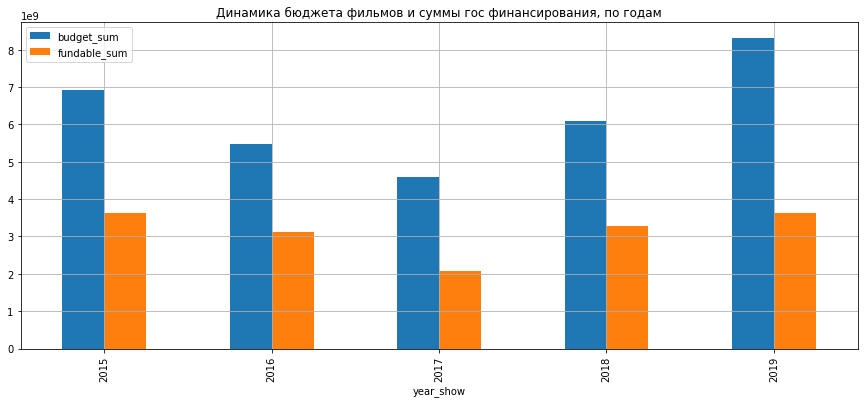

In [125]:
# Построим график изменения бюджета фильмов и гос. финансирования , в зависимости от года.
fundable_analysis.query('year_show > 2014')\
.plot(kind ='bar',
      y=['budget_sum',
         'fundable_sum'],
      secondary_y ='fundable_part',
      grid=True, figsize=(15,6),
      title = 'Динамика бюджета фильмов и суммы гос финансирования, по годам')
plt.show()

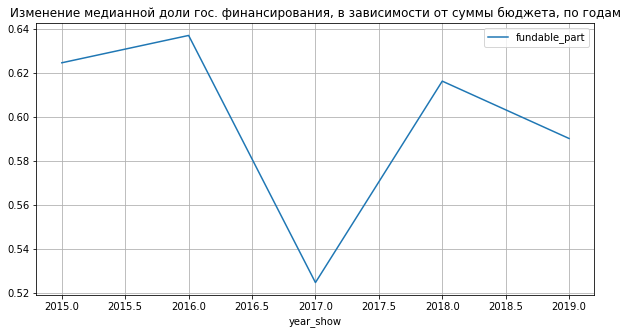

In [126]:
# Построим график динамики медианной доли гос. финансирования.
movies.query('year_show > 2014')\
.pivot_table(index ='year_show', values ='fundable_part', aggfunc ='median')\
.plot(y='fundable_part',
      figsize = (10,5),
      grid=True,
      title = 'Изменение медианной доли гос. финансирования, в зависимости от суммы бюджета, по годам')
plt.show()

По графикам видно, что из года в год общая сумма бюджетов на производство фильмов изменялась с падениями и ростом практически в 2 раза. При этом можно отметить, что сумма гос. финансирования в независимости от динамики изменения бюджета колеблется в рамках 53%-63%. Вероятно существует фиксированная норма доли гос. финансирования, на основании которой выделяются денежные средства на поддержку.

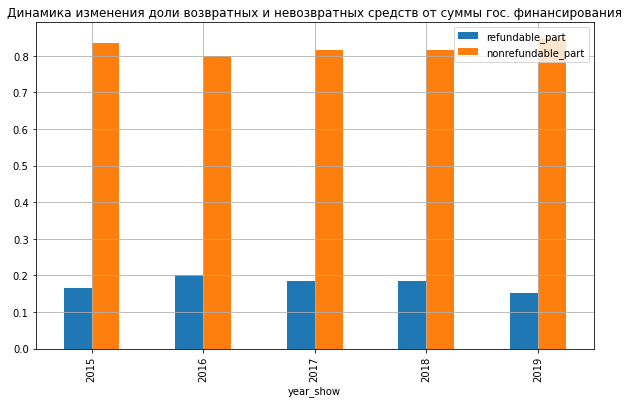

In [127]:
# Построим график изменения доли возвратных и невозвратных средств от суммы гос. финансирования
fundable_analysis.query('year_show > 2014')\
.plot(kind ='bar',
      y=['refundable_part','nonrefundable_part'],
      grid=True, figsize=(10,6),
      title = 'Динамика изменения доли возвратных и невозвратных средств от суммы гос. финансирования')
plt.show()

При этом сумма гос. финансирования стабильно делится на 2 части: 80%- 85% это сумма невозвратных средств, а 15%-20% это сумма возвратных средств. В данном случае также прослеживаются нормы финансирования.

### Определение доли финансируемых фильмов от кол-ва российских аккредитованных фильмов

In [128]:
# Сформируем сводную таблицу с количеством финансируемых фильмов.
title_fundable = movies.query('year_show > 2014 and fundable_total > 0').pivot_table(index ='year_show', values ='title', aggfunc ='count' )
title_fundable.columns = ['title_fundable_count']

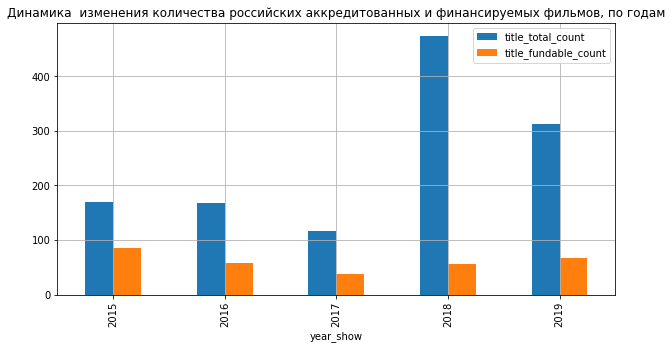

In [129]:
# Сформируем сводную таблицу с количеством российских аккредитованных фильмов.
title_total = movies.query('year_show > 2014 and country_first == "Россия"').pivot_table(index ='year_show', values ='title', aggfunc ='count' )
title_total.columns = ['title_total_count']
# Объединим данные с количеством финансируемых фильмов.
title_total =title_total.join(title_fundable)
title_total['title_fundable_part'] = title_total['title_fundable_count']/title_total['title_total_count']
# Построим график 
title_total.plot(
    y=['title_total_count','title_fundable_count'],
    kind ='bar',
    figsize = (10,5),
    grid=True,
    title = 'Динамика  изменения количества российских аккредитованных и финансируемых фильмов, по годам')
plt.show()

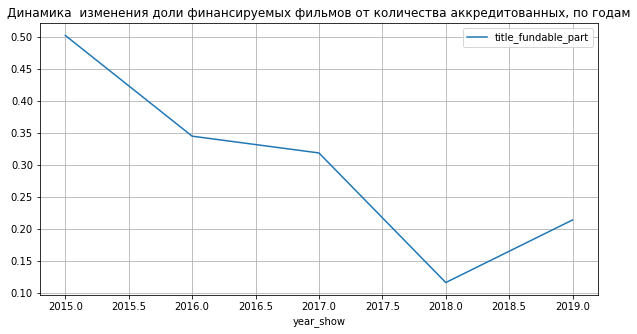

In [130]:
# Построим график изменения доли количества финансируемых фильмов
title_total.plot(y='title_fundable_part',
                 figsize = (10,5),
                 grid=True,
                 title = 'Динамика  изменения доли финансируемых фильмов от количества аккредитованных, по годам')
plt.show()

**В зависимости от количества аккредитованных фильмов зависимость меньше прослеживается. Мы ранее выявили, что в 2018-2019 году было выпущено повышенное кол-во фильмов , предназначенных не для кинотеатров, а для ТВ, поэтому такео резкое падение доли финансируемых фильмов от кол-ва аккредитованных.**

**Посмотрим как влияет на сумму гос. финансирования, возвратных и невозвратных средств бюджет фильма.**

### Определение влияния бюджета  фильма на сумму гос. финансирования, возвратных и невозвратных средств

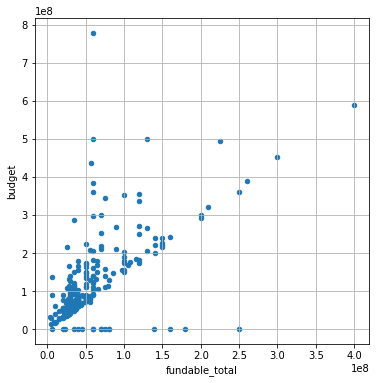

In [131]:
# Построение диаграмм рассеяния влияния бюджета фильма на сумму гос. бюджетирования
movies.plot(x='fundable_total', y='budget', kind='scatter', grid=True, figsize=(6, 6))
plt.show()

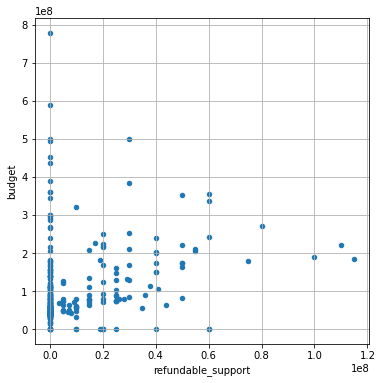

In [132]:
# Построение диаграмм рассеяния влияния бюджета фильма на сумму возвратных средств гос. бюджетирования
movies.plot(x='refundable_support', y='budget', kind='scatter', grid=True, figsize=(6, 6))
plt.show()

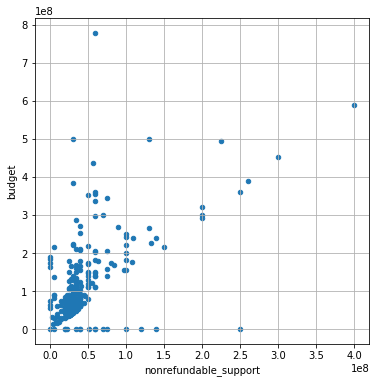

In [133]:
# Построение диаграмм рассеяния влияния бюджета фильма на сумму невозвратных средств гос. бюджетирования
movies.plot(x='nonrefundable_support', y='budget', kind='scatter', grid=True, figsize=(6, 6))
plt.show()

In [134]:
# Рассчитаем коэффициенты корреляции
movies[['fundable_total','nonrefundable_support','refundable_support', 'budget']].corr()

,fundable_total,nonrefundable_support,refundable_support,budget
fundable_total,1.00,0.93,0.37,0.64
nonrefundable_support,0.93,1.00,-0.01,0.58
refundable_support,0.37,-0.01,1.00,0.26
budget,0.64,0.58,0.26,1.00


**Коэффициент корреляции общего гос. финансирования от суммы бюджета равен 0,64. Влияние выше среднего, что подтверждает гипотезу об определенных государственных нормах.**

**Также коэффициент корреляции 0,93 подтверждает прямую зависимость суммы невозвратных средств от общей суммы гос. финансирования, ранее мы отметили долю 80%.**

**А сумма возвратных средств уже имеет слабую связь с общей суммой гос. финансирования. Возможно, в данном случае, работает другая закономерность, например, кредитование экспериментальных или специфических проектов или определенных жанров.**

**Рассмотрим, какие типы фильмов и жанры финансируются.**

### Определение типов и жанров финасируемых фильмов

In [135]:
# Формирование сводной таблицы с типами фильмов
type_analysis = movies.query('year_show > 2014')\
.pivot_table(index='year_show',
             columns = 'type',
             values = ['budget','refundable_support','nonrefundable_support','fundable_total'],
             aggfunc='sum')
type_analysis

budget                                            \
type      Анимационный Документальный Музыкально-развлекательный   
year_show                                                          
2015         671632271              0                       <NA>   
2016         776298665              0                       <NA>   
2017         865701169              0                       <NA>   
2018        1179689748              0                       <NA>   
2019        1095567667       33000000                          0   

                                                  fundable_total  \
type      Научно-популярный Прочие Художественный   Анимационный   
year_show                                                          
2015                   <NA>      0     6238961610      455000000   
2016                      0      0     4703159680      361520000   
2017                      0      0     3721878627      265000000   
2018                      0      0     4908220169      658969465   
2019                      0      0     7185224639      720000000   

                                                                       ...  \
type      Документальный Музыкально-развлекательный Научно-популярный  ...   
year_show                                                              ...   
2015                   0                       <NA>              <NA>  ...   
2016                   0                       <NA>                 0  ...   
2017                   0                       <NA>                 0  ...   
2018                   0                       <NA>                 0  ...   
2019             3000000                          0                 0  ...   

               nonrefundable_support                                          \
type      Музыкально-развлекательный Научно-популярный Прочие Художественный   
year_show                                                                      
2015                            <NA>              <NA>      0     2679088340   
2016                            <NA>                 0      0     2223031000   
2017                            <NA>                 0      0     1529624781   
2018                            <NA>                 0      0     2261000000   
2019                               0                 0      0     2663000000   

          refundable_support                                            \
type            Анимационный Документальный Музыкально-развлекательный   
year_show                                                                
2015               115000000              0                       <NA>   
2016                95000000              0                       <NA>   
2017                95000000              0                       <NA>   
2018               255000000              0                       <NA>   
2019               300000000              0                          0   

                                                   
type      Научно-популярный Прочие Художественный  
year_show                                          
2015                   <NA>      0      482153119  
2016                      0      0      526500000  
2017                      0      0      289346881  
2018                      0      0      347000000  
2019                      0      0      248000000  

[5 rows x 24 columns]

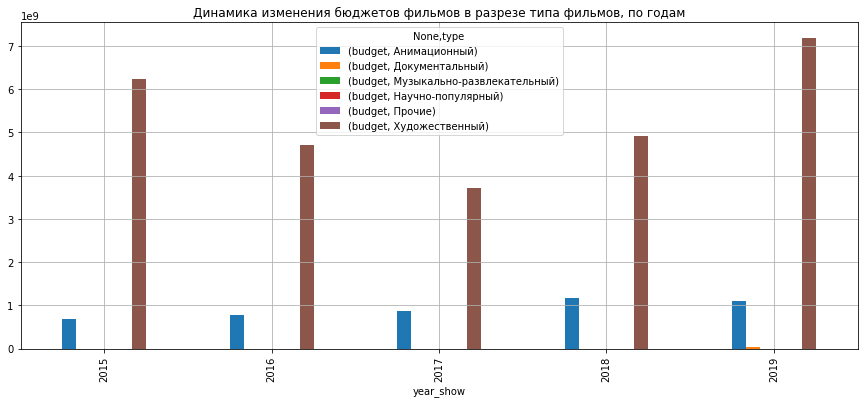

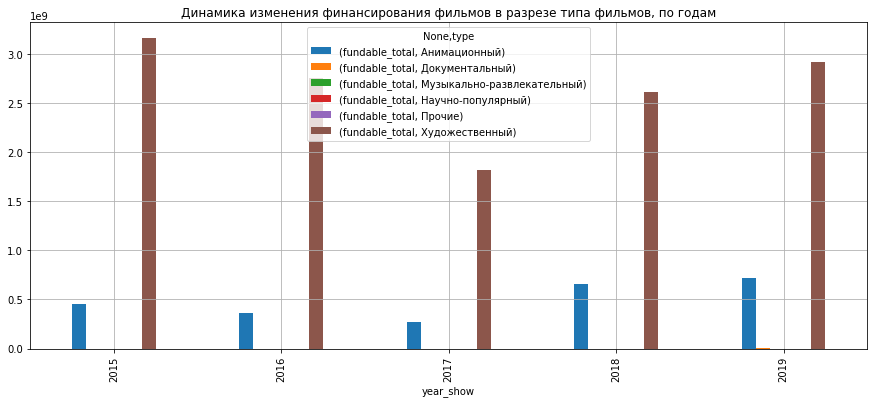

In [136]:
# Выведем графики
type_analysis.plot(kind ='bar',
                   y=['budget'],
                   grid=True,
                   figsize=(15,6),
                   title = 'Динамика изменения бюджетов фильмов в разрезе типа фильмов, по годам')
plt.show()
type_analysis.plot(kind ='bar',
                   y=['fundable_total'],
                   grid=True,
                   figsize=(15,6),
                   title = 'Динамика изменения финансирования фильмов в разрезе типа фильмов, по годам')
plt.show()

**Больше всего бюджетов на производство фильмов и финансирование собрали Художественные фильмы.**


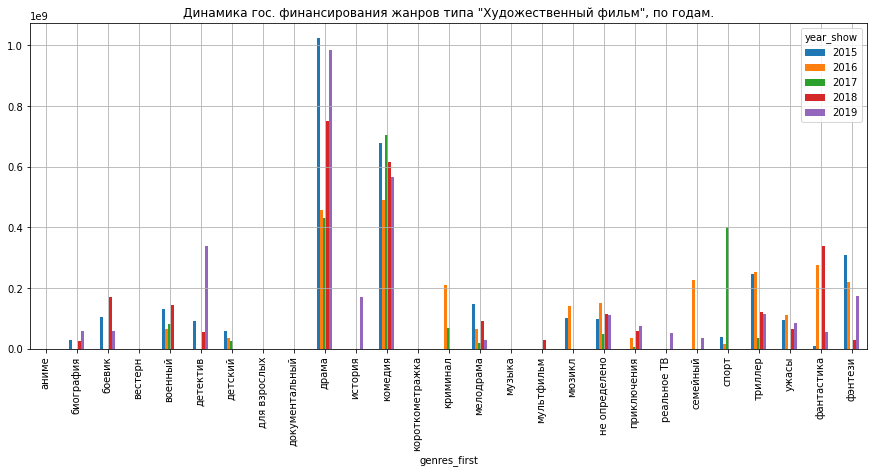

In [137]:
# Формируем сводную таблицу по жанрам финанасируемых фильмов типа Художественных фильмов и выведем график
(
    movies.query('type == "Художественный" and year_show > 2014')
    .pivot_table(index = 'genres_first', columns = 'year_show', values = 'fundable_total', aggfunc ='sum')
    .plot(kind ='bar',
          grid=True,
          figsize=(15,6),
          title = 'Динамика гос. финансирования жанров типа "Художественный фильм", по годам.')
)
plt.show()

### Определение возрастной категории финасируемых фильмов

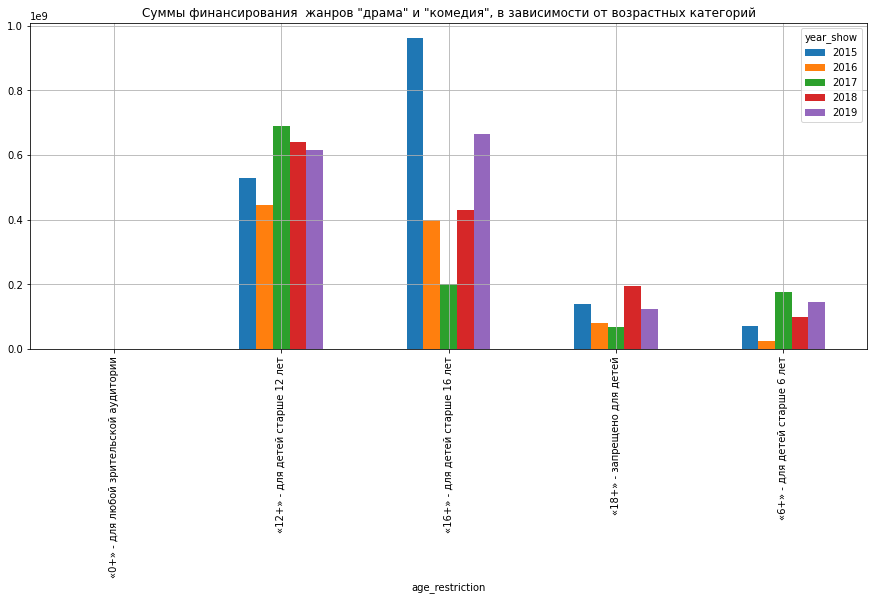

In [138]:
# Выведем возрастные категории финансируемых  жанров "драма" и "комедия".
(
    movies.query(
        'type == "Художественный" and (genres_first == "драма" or genres_first == "комедия") and year_show > 2014')
    .pivot_table(index = 'age_restriction', columns = 'year_show', values = 'fundable_total', aggfunc ='sum')
    .plot(kind ='bar',
          grid=True, 
          figsize=(15,6),
          title = 'Суммы финансирования  жанров "драма" и "комедия", в зависимости от возрастных категорий')
)
plt.show()

**Больше всего каждый год выделяется средств на художественные фильмы жанров "драма" и "комедия", в возрастной категории 12+ и 16+.**

### Определение самого дорогостоящего жанра

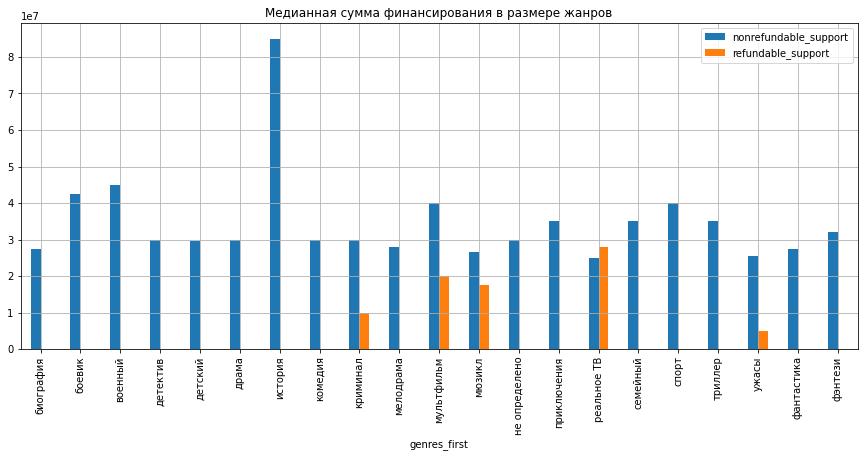

In [139]:
# Выведем медианную сумму распределения финансирования по жанрам
(
    movies.query('year_show > 2014 ')
    .pivot_table(index = 'genres_first', values=['refundable_support','nonrefundable_support'], aggfunc='median')
    .plot(kind ='bar',
          grid=True, 
          figsize=(15,6),
          title = 'Медианная сумма финансирования в размере жанров')
)
plt.show()

**Если рассматривать жанры по сумме  финасирования, то самые дорогие исторические фильмы. При этом можно отметить, что кредитные средства выдаются на ограниченный список жанров, что подтверждает гипотезу, что возвратные средства выдаются на экспериментальные или рискованные проекты, на непопулярные жанры, или жанры с высоким возрастным ограничением.**

### Анализ рейтингов финансируемых фильмов

**Рассмотрим, какие рейтинги получают финасирумые фильмы.**

In [140]:
# Выведем основную статистику по рейтингам российских фильмов
movies.query('year_show > 2014 and country_first == "Россия"')['ratings'].describe()

count   791.00
mean      6.32
std       1.13
min       1.00
25%       5.60
50%       6.40
75%       7.10
max       9.40
Name: ratings, dtype: float64

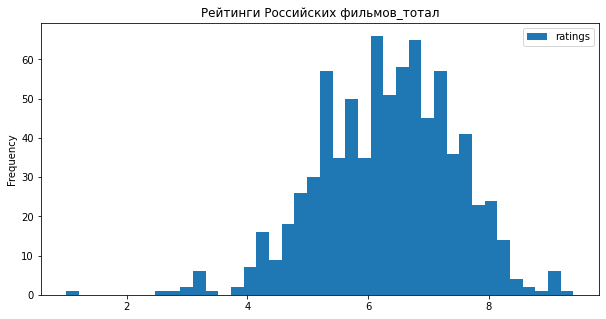

In [141]:
# Выведем гистограмму рейтингов российских фильмов
movies.query('year_show > 2014 and country_first == "Россия"').plot(
    kind='hist',
    y='ratings',
    bins=40,
    figsize = (10,5),
    title = 'Рейтинги Российских фильмов_тотал')
plt.show()  

In [142]:
# Выведем основную статистику по рейтингам финансируемых фильмов
movies.query('year_show > 2014 and fundable_total > 0')['ratings'].describe()

count   287.00
mean      6.01
std       1.15
min       1.00
25%       5.30
50%       6.20
75%       6.70
max       9.40
Name: ratings, dtype: float64

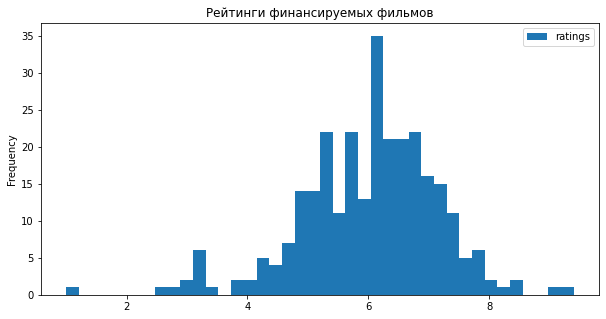

In [143]:
# Выведем гистограмму рейтингов финасируемых фильмов
movies.query('year_show > 2014 and fundable_total > 0').plot(
    kind='hist',
    y='ratings',
    bins=40,
    figsize = (10,5),
    title = 'Рейтинги финансируемых фильмов')
plt.show() 

**Средний и медианный рейтинги финансируемых и всех российских фильмов можно сказать одинаковые, но у всех российских фильмов пики рейтингов больше размазаны: 5,6; 5,8; 6,1; 6,9; 7,1.**

**А у финансируемых фильмов основной пик один, на отметке 6,2. Рейтинг средний, но более стабильный.**

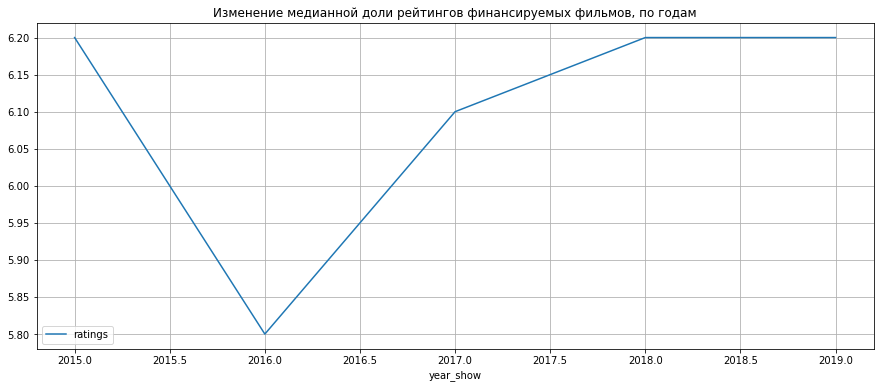

In [144]:
# Построение графика изменения медианной доли рейтингов финансируемых фильмов, по годам
(
    movies.query('year_show > 2014 and fundable_total > 0 ')
    .pivot_table(index = 'year_show', values='ratings', aggfunc='median')
    .plot( grid=True,
          figsize=(15,6),
          title = 'Изменение медианной доли рейтингов финансируемых фильмов, по годам')
)
plt.show()

In [145]:
# Выделим топ жанров 
genres_ratings = movies.query('year_show > 2014 and fundable_total > 0').pivot_table(index = 'genres_first', values='ratings', aggfunc=['count','median'])
genres_ratings.columns = ['count','median']
genres_ratings.sort_values(by='count',ascending=False)

,count,median
genres_first,,
драма,81,6.40
комедия,71,5.80
мультфильм,29,6.20
триллер,15,5.60
мелодрама,13,5.90
ужасы,10,5.10
фэнтези,10,6.10
военный,9,6.40
фантастика,8,6.75


**Топ-3 жанра, по которым больше всего информации по собранным рейтингам: драма, комедия и мультфильм.**

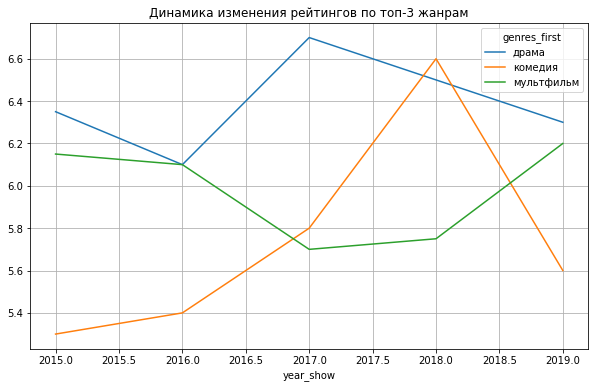

In [146]:
(
    movies.query(
        'year_show > 2014\
        and fundable_total > 0\
        and (genres_first=="драма" or genres_first=="комедия" or genres_first=="мультфильм" )')
        .pivot_table(index = 'year_show', columns = 'genres_first', values='ratings', aggfunc='median')
        .plot( grid=True,
              figsize=(10,6),
              title = 'Динамика изменения рейтингов по топ-3 жанрам')
)
plt.show()

**Более высокую оценку в динамике по годам получили финансируемые фильмы жанра "драма".**

**Выведем топ-20 финансируемых фильмов с высокими рейтингами.**

In [147]:
(
    movies.query(
        'year_show > 2014\
        and fundable_total > 0\
        and (genres_first=="драма" or genres_first=="комедия" or genres_first=="мультфильм" )')
    .sort_values(by='ratings', ascending=False)
    .head(20)
)

,pu_number,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,...,genres,box_office,ratings_nan,genres_nan,year_show,genres_first,director_first,fundable_total,fundable_part,country_first
3138,111019615,Я умею вязать,2015-11-27,Художественный,"ООО ""Белое Зеркало""",Россия,Н.Степанова при участии С.Иванова,"С.Кикнавелидзе, Д.Улюкаев",«16+» - для детей старше 16 лет,0,...,драма,801370.00,False,False,2015,драма,Н.Степанова при участии С.Иванова,4700000,0.32,Россия
1869,111002915,А зори здесь тихие..._,2015-03-16,Художественный,"ООО ""Компания ""Реал-Дакота""",Россия,Р.Давлетьяров,не определено,«12+» - для детей старше 12 лет,50000000,...,"драма,военный,история",249166767.70,False,False,2015,драма,Р.Давлетьяров,150000000,0.68,Россия
6854,111006719,Миллиард,2019-04-17,Художественный,"ООО ""Медиа Юниверсал Ивент""",Россия,Р.Прыгунов,"В.Маслов, В.Верещагин, Б.Анисимов",«12+» - для детей старше 12 лет,0,...,драма,408646665.70,False,False,2019,драма,Р.Прыгунов,140000000,0.58,Россия
3781,111001617,Мотылёк.,2017-03-22,Художественный,"ООО ""Кинокомпания КИТ""",Россия,К.Худяков,"Е.Бабенко, В.Ремизов",«18+» - запрещено для детей,7346881,...,драма,410058.00,False,False,2017,драма,К.Худяков,37346881,0.59,Россия
2481,111004215,Однажды._,2015-04-15,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА"", НП ""Интерфест""",Россия,Р.Давлетьяров,"Р.Давлетьяров, А.Котелевский",«16+» - для детей старше 16 лет,0,...,"драма,криминал,детектив",12748398.30,False,False,2015,драма,Р.Давлетьяров,97000000,0.62,Россия
7321,111018519,Успех,2019-11-04,Художественный,"ООО ""Кинодом""",Россия,П.Руминов,"С.Бобза, Г.Малков, В.Поляков, М.Кучмент",«12+» - для детей старше 12 лет,5000000,...,драма,3181218.00,False,False,2019,драма,П.Руминов,25000000,0.33,Россия
3656,111011816,Простая история .,2016-07-19,Художественный,"ООО ""КИНОБЮРО""",Россия,В.Татарский,Ю.Бахшиев,«16+» - для детей старше 16 лет,0,...,"драма,биография",58720.00,False,False,2016,драма,В.Татарский,64000000,0.36,Россия
7106,111012319,Сестренка,2019-09-19,Художественный,"ЗАО ""Мотор фильм студия""",Россия,А.Галибин,"Т.Каримов, М.Курбатов, Д.Фикс",«6+» - для детей старше 6 лет,0,...,"драма,военный",27853374.23,False,False,2019,драма,А.Галибин,40000000,0.62,Россия
3156,111019515,ХИТ,2015-11-27,Художественный,"ООО ""Дип Коммьюникейшн""",Россия,М.Михайлова,"Е.Яцура, В.Кузнецов",«16+» - для детей старше 16 лет,0,...,"драма,комедия",129333.50,False,False,2015,драма,М.Михайлова,21700000,0.59,Россия
6077,111012618,Один день лета,2018-09-15,Художественный,"ООО МИП ""Продюсерский центр СПбГИКиТ-Дебют""",Россия,А.Игудин,"А.Евменов, А.Смирнов",«16+» - для детей старше 16 лет,0,...,"драма,мелодрама",279013.50,False,False,2018,драма,А.Игудин,25000000,0.66,Россия


### Изучение окупаемости фильмов в прокате

In [148]:
# Добавим колонку с долей соборов в прокате от суммы бюджета
movies['payback'] = movies['box_office']/movies['budget']

,box_office_count,budget_count,count_part
year_show,,,
2015,78,79,0.99
2016,54,55,0.98
2017,33,35,0.94
2018,51,51,1.00
2019,57,66,0.86


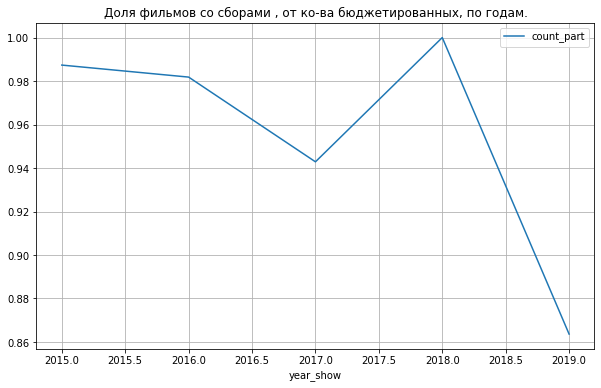

In [149]:
# Сформируем сводную таблицу по количеству бюджетируемых фильмов и фильмов со сборами
box_office_analysis = movies.query('budget > 0 and year_show > 2014').pivot_table(index= 'year_show', values=['budget', 'box_office'], aggfunc=['count'])
box_office_analysis.columns = ['box_office_count','budget_count']
box_office_analysis['count_part'] = box_office_analysis['box_office_count']/box_office_analysis['budget_count']
box_office_analysis.plot( y ='count_part', grid=True, figsize=(10,6), title = 'Доля фильмов со сборами , от ко-ва бюджетированных, по годам.')
box_office_analysis

**Каждый год больше 90% бюджетируемых фильмов собирали какую-то сумму с прокатов. Только в 2019 году процент упал до 86%.
Ниже список фильмов в 2019 году, по которым отсутсвует ифнормация по прокатам. В списке есть фильмы, у которых дата старта проката конец года, можно только предположить , что даты проката  были перенесены на начало 2020 года, но в 2020 случился Ковид и все прокаты были надолго приостановлены.**



In [150]:
movies.query('budget > 0 and year_show == 2019 and box_office.isna()')

,pu_number,title,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,...,box_office,ratings_nan,genres_nan,year_show,genres_first,director_first,fundable_total,fundable_part,country_first,payback
6475,111023518,Зима,2019-03-15,Художественный,"ООО ""КиноТрест""",Россия,С.Черников,"З.Болотаев, А.Плотников, Н.Агеев, А.Горский, П...",«16+» - для детей старше 16 лет,0,...,NaN,False,False,2019,драма,С.Черников,25000000,0.63,Россия,NaN
6708,111002619,Мальчик русский,2019-02-20,Художественный,"АО ""Ленфильм""",Россия,А.Золотухин,не определено,«12+» - для детей старше 12 лет,0,...,NaN,False,False,2019,драма,А.Золотухин,30000000,0.64,Россия,NaN
6967,111008619,Танец с саблями,2019-05-29,Художественный,"ООО ""Кинокомпания Флагман"" по заказу ООО ""ММЕ""",Россия,Ю.Разыков,"Р.Дишдишян, ООО ""МАРС МЕДИА ЭНТЕРТЕЙНМЕНТ""",«16+» - для детей старше 16 лет,0,...,NaN,False,False,2019,драма,Ю.Разыков,40000000,0.65,Россия,NaN
7008,111010019,Куратор,2019-06-13,Художественный,"ООО ""Кинокомпания Атлантик"", 20 стэпс продакшнс",Россия - Грузия,П.Левченко,Е.Филиппова,«16+» - для детей старше 16 лет,0,...,NaN,False,False,2019,драма,П.Левченко,25000000,0.41,Россия - Грузия,NaN
7179,112004619,Байкал - Сердце мира 3D,2019-11-01,Документальный,"ООО ""Продюсерский центр ""Новое Время""",Россия,А.Попова,"И.Добровольский, А.Разуваева, Ю.Перкуль",«0+» - для любой зрительской аудитории,0,...,NaN,False,False,2019,семейный,А.Попова,3000000,0.09,Россия,NaN
7228,111015519,На Луне,2019-11-01,Художественный,"ООО ""Киностудия ""ВЕРТИКАЛЬ""",Россия,Е.Михалков-Кончаловский,"С.Говорухин, Е.Маскина",«16+» - для детей старше 16 лет,0,...,NaN,False,False,2019,приключения,Е.Михалков-Кончаловский,35000000,0.60,Россия,NaN
7343,111018919,Кроличья лапа,2019-11-20,Художественный,"ООО ""Зебра"", ""Артемис"", ""Гринлит""","Россия, Бельгия, Финляндия",Н.Джорджадзе,Ю.Соболевская,«16+» - для детей старше 16 лет,0,...,NaN,True,True,2019,не определено,Н.Джорджадзе,30000000,0.63,Россия,NaN
7475,111023019,Я свободен,2019-12-26,Художественный,"АО ""ТПО ""Киностудия им. М.Горького""",Россия,И.Северов,С.Зернов,«12+» - для детей старше 12 лет,0,...,NaN,False,False,2019,драма,И.Северов,30000000,0.65,Россия,NaN
7477,111023119,(Не)идеальный мужчина,2019-12-24,Художественный,"ООО ""Нон-Стоп Продакшн""",Россия,М.Бальчюнас (псевдоним М.Вайсберг),"С.Мелькумов, А.Роднянский, М.Вайсберг, Р.Минас...",«12+» - для детей старше 12 лет,40000000,...,NaN,False,False,2019,комедия,М.Бальчюнас (псевдоним М.Вайсберг),100000000,0.67,Россия,NaN


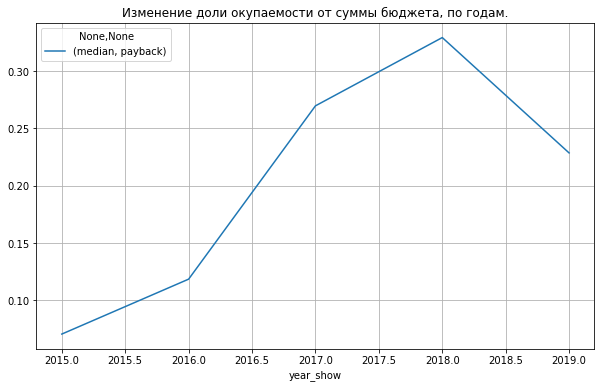

In [151]:
# Изменение доля окупаемости от суммы бюджета, по годам.
movies.query('budget > 0 and year_show > 2014 ')\
.pivot_table(index= 'year_show', values=['payback'], aggfunc=['median'])\
.plot( grid=True,
      figsize=(10,6),
      title = 'Изменение доли окупаемости от суммы бюджета, по годам.')
plt.show()

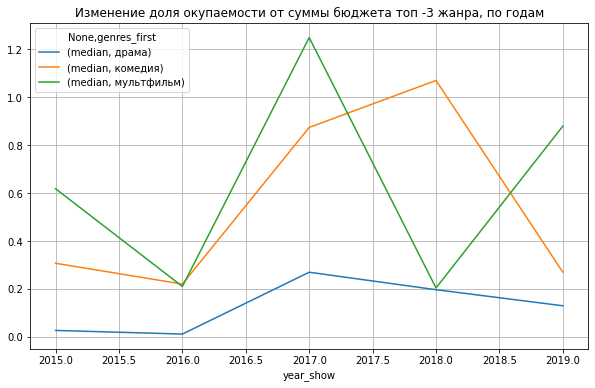

In [152]:
# Изменение доля окупаемости от суммы бюджета топ -3 жанра, по годам.
movies.query('budget > 0 and year_show > 2014\
and (genres_first=="драма" or genres_first=="комедия" or genres_first=="мультфильм" ) ')\
.pivot_table(index= 'year_show', columns = 'genres_first', values='payback', aggfunc=['median'])\
.plot( grid=True,
      figsize=(10,6),
      title = 'Изменение доля окупаемости от суммы бюджета топ -3 жанра, по годам')
plt.show()

**Доля окупаемости от суммы бюджета фильма очень низкая, не превышающая в общем 40%. Однако в разрезе топ-3 жанра, мультфильмы и комедии достигали 100% окупаемости, а у драм максимальная сумма сборов не превышала 30% от суммы бюджета фильма.**

**Проверим зависимость суммы сборов от размера бюджета фильма и рейтинга.**

### Изучение влияния рейтинга и бюджета фильма на окупаемость

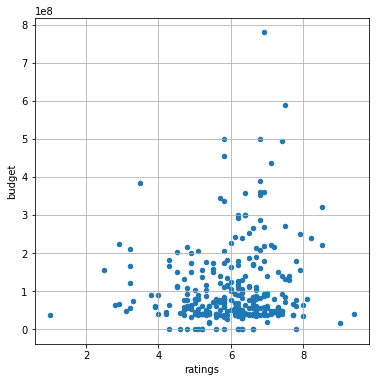

In [153]:
# Построение диаграмм рассеяния влияния рейтинга от бюджета фильма
movies.plot(x='ratings', y='budget', kind='scatter', grid=True, figsize=(6, 6))
plt.show()

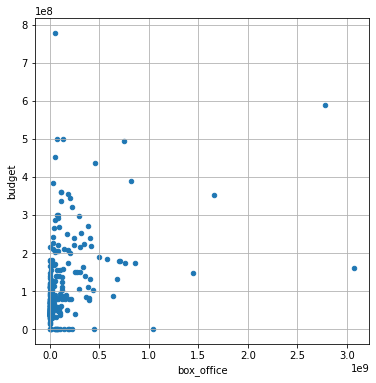

In [154]:
# Построение диаграмм рассеяния влияния сборов с проката от бюджета фильма
movies.plot(x='box_office', y='budget', kind='scatter', grid=True, figsize=(6, 6))
plt.show()

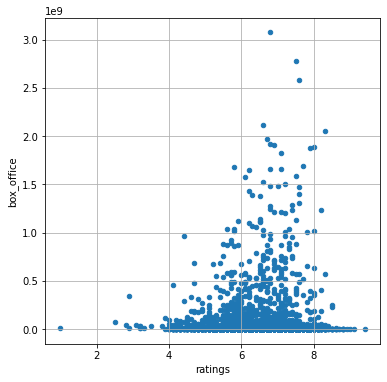

In [155]:
# Построение диаграмм рассеяния влияния сборов с проката от рейтинга фильма
movies.plot(x='ratings', y='box_office', kind='scatter', grid=True, figsize=(6, 6))
plt.show()

In [156]:
movies[['budget','ratings','box_office']].corr()

,budget,ratings,box_office
budget,1.00,0.12,0.37
ratings,0.12,1.00,0.08
box_office,0.37,0.08,1.00


**Существует слабая связь суммой сборов с прокатов от суммы бюджета фильма, коэффициент корреляции равен 0,37.**

**Сумма сборов не зависит от рейтинга фильма.**

**И также рейтинг не зависит от бюджета фильма.**


## Общий вывод

**Для проведения анализа были выполнены следующие шаги:**

**1. Объединены в один датафрейм две таблицы: реестр прокатных удостоверений и реестр данных о прокате.**

**2. Выполнена предобработка данных.**

**2.1 Были изменены типы данных в колонках:**

 - refundable_support 

 - nonrefundable_support 

 - budget 

 - show_start_date 

 - ratings 

**2.2 Заполнены пропуски в колонках:**

 - film_studio
 
 - director

 - production_country 

 - producer 

 - financing_source 

 - genres

Пропуски в колонках с количественными данными, такие как суммы финансирования, рейтинги, сборы являются неслучайными. Не все фильмам была оказана гос. поддержка , также вероятно не все фильмы вышли в прокат или набрали достаточное кол-во данных для формирования рейтингов.

Пропуски в категориальных столбцах скорее всего обосновываются оишбками в ручном заполнении данных.

**2.3 Проведена проверка и обработка дубликатов**

**2.4 Изучены категориальные столбцы, устранены аномалии в колонке "type".**

**2.5 Изучены количественные столбцов, выявлены и обработаны выбросы в данных.**

**2.6 Добавлены новые столбцы с указанием года выхода в прокат, главного жанра и первого режиссера фильма.**

**3. Проведен исследовательский анализ фильмов , вышедших в прокат.**

с 2010 по 2019 год в год аккредитовалось от 500 до 1000 фильмов, но данные о прокате фильмов более полные начинаются с 2015 года, самая полная информация по прокатам фильмов в 2015-2017 годах, а именно, по порядку 65%, 63%, 71% от кол-ва аккретованных фильмов. В 2018 году доля вышедших в прокат резко упала до 54% от всех аккредитованных фильмов. Это связано с тем, что в 2018 и 2019 гг. резко увеличилось кол-во Документальных и Анимационных фильмов сериального формата, для показа на ТВ.

в 2015 году была самая маленькая сумма проката, 39 000 млн. руб. И далее с каждым годом сумма проката росла, в 2019 году сумма проката выросла до 48 000 млн. руб.

топ - 5 жанров по сборам в прокате, последовательно по уменьшению: фантастика, мультфильмы, боевики, фэнтези, комедии. 

На первом месте по сборам фильмы с возрастным ограничением 16+. Это обуславливается несколькими факторами:

- Массивная представленность ассортимента для просмотра, большое кол-во фильмов на выбор.

- Аудитория: Одна из самых лояльных аудиторий для посещения кинотеатров - активная молодежь.

- Широкий охват: фильмы на широкую аудиторию. В том числе, самый популярный жанр, собирающий большие сборы - фантастика. Фильмы в жанре фантастика всегда привлекают зрелищностью и в то же время в подобных фильмах чаще всего минимум специфической нагрузкой, которые могут ограничивать в возрасте, в отличие от триллеров, сложных драм или ужасов.

- Выход несколько лет подряд культовых фильмов, трилогии, такие как Пираты карибского моря, а также фильмы по мотивам комиксов. Скорее всего выбросы в суммах сборов обсулавливаются выходами таких фильмов.

А также хочется отметить сборы для возраста 6+. Сам по себе возраст 6+ ограничивает охват аудитории, тем , что просмотр рассчитан на детей, которые зависят от родителей. Количество фильмов в прокате было в 2 раза меньше в сравнении с количеством 16+.  Однако в данной категории вышли ряд очень успешных мультипликационных фильмов, которые собрали самые большие суммы среди всех всех фильмов , всех жанров. Это мультики, которые можно оценить как мультики не только для детей, но и для взрослых, такие как Зверополис, Движение вверх, которые произвели большое впечатление на взрослую аудиторию.

**4. Проведен исследовательский анализ фильмов, которые получили государственную поддержку.**


По итогам анализа выявлено, что существует норма гос. поддержки, в независимости от объёма денежных средств финансирование осуществляется в рамках 53%-63% от бюджета производства фильмов. 80% всех выданных средств невозвратные. Остальные 20% кредитные средства, предназначенные к возврату, чаще всего выдаются на ограниченный список жанров, на экспериментальные или рискованные проекты, на непопулярные жанры, или жанры с высоким возрастным ограничением.  

Больше всего каждый год выделяется средств на художественные фильмы жанров "драма" и "комедия", в возрастной категории 12+ и 16+. 

Самый распространенный рейтинг среди финансируемых фильмов по данным Кинопоиска 6,2. В целом, такой рейтинг у всех российских фильмов, которые были аккредитованы в аналогичные периоды с 2015 - 2019 гг. 

Топ-3 жанра, по которым больше всего информации по собранным рейтингам: драма, комедия и мультфильм, самый частый рейтинг для каждого из жанров, последовательно: 6,4;5,8;6,2

Более высокую оценку в динамике по годам получили финансируемые фильмы жанра "драма".

Однако, доля окупаемости по финансируемым фильмам в общей массе очень низкая, не превышающая в общем 40%. В разрезе топ-3 жанра, мультфильмы и комедии достигали 100% окупаемости, а у драм максимальная сумма сборов не превышала 30% от суммы бюджета фильма.

При этом на сумму сборов особо не влияют ни суммы бюджетов на производство фильма, ни рейтинги. 

Низкий уровень окупаемости связан с тем, что рынок кино наполнен соверешнно разным ассортиментом, голливудскими фильмами, которые давно обрели доверие среди российской аудитории, а на рынке российского кино был временный кризис. Из жизни можно вспомнить, что попытки всерьез завоевать аудиторию российским киноматографом возобновились в 2010-ые, а из исследования мы получили подтверждение, что с 2015 года всё больше развивается российское кино.

**Рекомендации:**

Для выявления дополнительных закономерностей проката кино можно также рассмотреть данные с точки зрения кол-ва зрителей и географического охвата в прокате.

